In [31]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
from scipy.stats import ks_2samp
from scipy.stats import mannwhitneyu
from scipy.stats import false_discovery_control
import re
import seaborn as sns

In [32]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

# How many interactions?

In [27]:
ccc = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc.csv', index_col=0)
ia1 = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/intact_direct.csv', index_col=0)
ia2 = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/intact_physical.csv', index_col=0)
ia3 = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/intact_association.csv', index_col=0)


In [28]:
ccc['type'] = 'CCI'
ia1['type'] = ia1['type'].replace({'non-enzymatic direct': 'IA Direct', 'enzymatic direct': 'IA Direct'})
ia2['type'] = ia2['type'].replace({'physical': 'IA Physical'})
ia3['type'] = ia3['type'].replace({'association': 'IA Association'})


In [29]:
df = pd.concat([ccc, ia1, ia2, ia3]).drop_duplicates()
df.to_csv('/home/lnemati/pathway_crosstalk/data/interactions/all_ccis_and_intact.csv')

In [30]:
df.type.value_counts()

type
IA Association    302042
IA Physical       111267
IA Direct           7852
CCI                 3991
Name: count, dtype: int64

# 2_GPCRS

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import os
import numpy as np
import scanpy as sc
import PyWGCNA
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import mannwhitneyu, false_discovery_control
import re
from itertools import combinations
from scipy.stats import pearsonr, ks_2samp
import ast
from PIL import Image
import os
from adjustText import adjust_text

In [54]:
def stack_triangle(df, col):
    df = pd.DataFrame(
        df.where(
            np.tri(
                df.shape[0],
                dtype=bool,
                k=-1
            ),
            np.nan
        ).stack(dropna=True), columns=[col] 
    )
    
    return df


In [55]:
# Function that generates and saves the ROC curve
def generate_roc_curve(
    data,
    target_col,
    feature_col,
):
    # ROC curve using all gene pairs
    fpr, tpr, thr = roc_curve(data[target_col], data[feature_col])
    auroc = roc_auc_score(data[target_col], data[feature_col])
    
    return fpr, tpr, thr, auroc

In [56]:
def fig_to_panels(fig, axes, output_dir):
    # Save individual panels of a figure 
    
    for panel_name, ax in axes.items():
        # Extract the panel title
        panel_title = ax.get_title()

        # Sanitize the panel title to use in filenames
        safe_title = panel_title.replace(" ", "_").replace("/", "_").replace("\n", "_").lower()

        # Create the filename for the current panel
        output_file = os.path.join(output_dir,safe_title)

        # Adjust the bounding box to include everything (labels, titles, etc.)
        extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

        # Save the individual panel using the adjusted bounding box
        fig.savefig(output_file + '.pdf', bbox_inches=extent, dpi=300)
        fig.savefig(output_file + '.png', bbox_inches=extent)

        print(f"Saved panel '{panel_title}' to {output_file}")


In [57]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

In [58]:
def network_to_adj(network_path):
    network = pd.read_csv(
        network_path,
        usecols=['complex1', 'complex2', 'adj']
    )

    # Add a mirrored version of the network to make it symmetric
    network_mirrored = network.copy()
    network_mirrored.columns = ['complex2', 'complex1', 'adj']
    network = pd.concat([network, network_mirrored], ignore_index=True)

    adj = network.pivot(index='complex1', columns='complex2', values='adj').fillna(0)
    return adj

# GPCRs

In [59]:
# Read GPCRs
gpcrs = pd.read_csv('/home/fraimondi/BIOINFO1_BK/francesco/GPCR/gpcrs_genes.txt')['Symbol'].values

# Read ligands
lr = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv')
lr = lr[lr.receptor.isin(gpcrs)]

# Read G-Proteins coupling
gprots_couplings = pd.read_csv('/home/lnemati/resources/gpcr_couplings/gpcr_couplings.csv')
gprots_couplings = gprots_couplings.query('n_sources >=3')
gprots_couplings = gprots_couplings.query('type != "precogx_only"')
gprots_couplings.set_index('gpcr', inplace=True, drop=False)
gprots_couplings.index.name = None
gprots_couplings = gprots_couplings.groupby('gpcr')['gprot'].apply(list)
gprots = gprots_couplings.values.sum()


In [60]:
# Get G-Proteins, GPCRs and their ligands
gpcrs_genes = set(gpcrs) | set(gprots) | set(lr.ligand.values) | set(lr.receptor.values)

In [61]:
ncoev = pd.read_csv('/home/lnemati/pathway_crosstalk/results/gpcrs/normal_jaccard_coevolution.csv', index_col=0)

df = pd.DataFrame(columns=['gpcr', 'interactor', 'interactor_type', 'condition', 'value'])

for gpcr in gprots_couplings.index.intersection(ncoev.index):
    couplings = ncoev.index.intersection(gprots_couplings.loc[gpcr])
    values = ncoev.loc[gpcr, couplings].to_frame(name = 'value')
    values['gpcr'] = gpcr
    values['interactor'] = values.index
    values['interactor_type'] = 'G-Protein'
    values['tissue'] = 'Coevolution'
    values['condition'] = 'Coevolution'
    values['value_type'] = 'jaccard'

    df = pd.concat([df, values])
    
for gpcr in ncoev.index.intersection(lr.receptor.unique()):
    ligands = ncoev.index.intersection(lr[lr['receptor'] == gpcr].ligand.unique())
    values = ncoev.loc[gpcr, ligands].to_frame(name = 'value')
    values['gpcr'] = gpcr
    values['interactor'] = values.index
    values['interactor_type'] = 'Ligand'
    values['tissue'] = 'Coevolution'
    values['condition'] = 'Coevolution'
    values['value_type'] = 'jaccard'

    df = pd.concat([df, values])

df = df.reset_index(drop=True)

In [62]:
df = pd.concat([df, pd.read_csv('/home/lnemati/pathway_crosstalk/results/gpcrs/all_gpcr_interactions.csv')])
#df = df[df['subtissue'] != 'testis']
df.query('not (subtissue == "testis" and condition == "normal")')
df = df.groupby(['gpcr', 'interactor', 'condition', 'interactor_type', 'tissue', 'value_type'], as_index=False)['value'].mean()
df = df.query('value_type in ["correlation", "jaccard"]')
df['condition'] =df['condition'].replace({'normal': 'Normal Co-Expression', 'tumor': 'Tumor Co-Expression'})

# Tumor Coevolution - GPCRS

In [63]:
df_complete = pd.read_csv('/projects/bioinformatics/DB/CancerTracer/intra_heterogeneity_data.txt', sep='\t')

# Remove wrongly formatted row
df_complete = df_complete[~df_complete.index.isin(['p075_p3'])]

In [64]:
import re
import pandas as pd

def extract_mutation_info(mutation_string, allowed_strings=None):
    # Return empty lists if the input string is missing or empty
    if pd.isna(mutation_string) or mutation_string == '':
        return [], [], []

    # Split the string into individual entries
    gene_entries = mutation_string.split(',')
    
    if allowed_strings is None:
        filtered_entries = [entry for entry in gene_entries]
    else:
    # Filter entries that have allowed patterns and contain a closing parenthesis
        filtered_entries = [entry for entry in gene_entries if any([x in entry for x in allowed_strings]) and ')' in entry]

    # Initialize lists to store genes, mutations, and samples
    genes = []
    mutations = []
    samples = []

    # Process each filtered entry
    for entry in filtered_entries:
        # Get gene: Keep only the text before the first set of parentheses
        gene = re.sub(r'\s*\(.*$', '', entry).strip()

        # Get mutation: Extract the content inside the parentheses
        mutation_match = re.search(r'\(([^()]*)\)', entry)
        mutation = mutation_match.group(1).strip() if mutation_match else ''

        # Get sample: Keep only the text after the first set of parentheses
        sample_match = re.search(r'\(.*?\)\s*([- ]*)(.*)', entry)
        sample = sample_match.group(2).strip('- ').strip() if sample_match else ''

        # Append the parsed components to respective lists
        genes.append(gene)
        mutations.append(mutation)
        samples.append(sample)

    # Return the lists of genes, mutations, and samples
    return genes, mutations, samples


In [65]:
dfs = []

for col in ['Trunk_mutation', 'Branch_mutation', 'Private_mutation']:
    # Separate individual mutations
    # Use regex to split only on commas that are not inside parentheses
    vals = df_complete[col].str.split(r',\s*(?![^(]*\))', expand=True)
    
    # Find nans
    keep = ~vals.isna()
    
    # Add sample ids
    samples = df_complete['Sample']
    samples.index = samples.values
    vals.index = samples.values
    vals = (vals.T.astype(str) + samples).T
    
    # Remove nans
    vals = vals.values[keep]

    #allowed_strings = ['(p.', '(amp', '(del']
    allowed_strings = ['(p.']
    #allowed_strings = None
    
    genes, mutations, samples = extract_mutation_info(", ".join(vals), allowed_strings = allowed_strings)
    
    #genes     = [get_gene(x)     for x in vals]
    #mutations = [get_mutation(x) for x in vals]
    #samples   = [get_sample(x)   for x in vals]
    
    mutations_df = pd.DataFrame()
    mutations_df.index = genes
    mutations_df['mutation'] = mutations
    mutations_df['patient'] = samples
    mutations_df['when'] = col.strip('_mutation')
    
    dfs.append(mutations_df)
    
mutations_df = pd.concat(dfs)
mutations_df['gene'] = mutations_df.index

mutations_df = mutations_df[~mutations_df.index.isin(['', ' ', '-'])]
mutations_df = mutations_df[~mutations_df['patient'].isin(['', ' ', '-'])]
mutations_df = mutations_df[~mutations_df['gene'].isin(['', ' ', '-'])]

In [66]:
# Read GPCRs
gpcrs = pd.read_csv('/home/fraimondi/BIOINFO1_BK/francesco/GPCR/gpcrs_genes.txt')['Symbol'].values

# Read ligands
lr = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv')
gpcrs_lr = lr[lr.receptor.isin(gpcrs)]
gpcrs_ligands = list(set(gpcrs_lr.ligand))

# Read G-Proteins coupling
gprots_couplings = pd.read_csv('/home/lnemati/resources/gpcr_couplings/gpcr_couplings.csv')
gprots = list(set(gprots_couplings.gprot))

gprots_couplings = gprots_couplings.query('n_sources >= 3')
gprots_couplings = gprots_couplings.query('type != "precogx_only"')
gprots_couplings.set_index('gpcr', inplace=True, drop=False)
gprots_couplings.index.name = None
gprots_couplings = gprots_couplings.groupby('gpcr')['gprot'].apply(list)


In [67]:
ccc_genes = set(lr.receptor).union(lr.ligand)

In [68]:
# Get G-Proteins, GPCRs and their ligands
gpcrs_genes = set(gpcrs) | set(gprots) | set(gpcrs_lr.ligand.values)# | set(gpcrs_lr.receptor.values)

In [69]:
mutations_df['gpcr']   = mutations_df.gene.isin(gpcrs)
mutations_df['gprot']  = mutations_df.gene.isin(gprots)
mutations_df['ligand'] = mutations_df.gene.isin(gpcrs_ligands)

In [70]:
mutations_df.index = (mutations_df['patient'] + '_' + mutations_df['gene'])
mutations_df['unique_id'] = (mutations_df['patient'] + '_' + mutations_df['gene'])

In [71]:
counts = mutations_df.groupby(['unique_id', 'when']).size().reset_index(name='count')
counts = counts.sort_values(by='count', ascending=False)
counts['patient'] = counts['unique_id'].str.split('_').apply(lambda x: '_'.join(x[:-1]))
counts['gene'] = counts['unique_id'].str.split('_').apply(lambda x: '_'.join(x[-1:]))

counts['ccc'] = False
counts.loc[counts.gene.isin(ccc_genes), 'ccc'] = True

In [72]:
genes = counts.groupby(['gene', 'when'])['count'].sum().to_frame()

In [73]:
genes['gene'] = genes.index.get_level_values(0)
genes['when'] = genes.index.get_level_values(1)
genes.index = range(len(genes))

In [74]:
# Group by 'gene' and calculate the total counts for each gene
total_counts = genes.groupby('gene')['count'].sum()

# Sort genes by total count in descending order
genes = genes.set_index('gene').loc[total_counts.sort_values(ascending=False).index].reset_index()

In [75]:
## Init dataframe for test results
results = pd.DataFrame(columns=['auroc', 'pval'])

genes_pivot = genes.pivot(index='gene', columns='when', values='count').fillna(0)
genes_pivot = genes_pivot.loc[total_counts.sort_values(ascending=False).index]

# All genes
genes_pivot_all = genes_pivot
total_all_log10 = np.log10(genes_pivot_all.sum(axis=1))
total_lig_log10 = total_all_log10.loc[total_all_log10.index.isin(gpcrs_ligands)]
total_gprot_log10 = total_all_log10.loc[total_all_log10.index.isin(gprots)]
total_gpcr_log10 = total_all_log10.loc[total_all_log10.index.isin(gpcrs)]

# Log10 Total comparisons
for label, subset, drop_ids in [
    ('ligand vs all', total_lig_log10, gpcrs_ligands),
    ('gprot vs all', total_gprot_log10, gprots),
    ('gpcr vs all', total_gpcr_log10, gpcrs)
]:
    others = total_all_log10.drop(drop_ids, errors='ignore')
    result = mannwhitneyu(subset, others)
    auroc = result.statistic / (len(subset) * len(others))
    results.loc[label, 'auroc'] = auroc
    results.loc[label, 'pval'] = result.pvalue
    results.loc[label, 'tested_quantity'] = 'Log10 Total'

# Apply multiple testing correction
results['pval_adj'] = false_discovery_control(results.pval.astype(float).values)


In [76]:
from itertools import combinations
import numpy as np
import pandas as pd

def compute_jaccards(sub_df):
    # Get unique patients per gene, filtered to GPCR genes
    patients_per_gene = (
        sub_df.groupby('gene')['patient']
        .unique()
        .loc[lambda x: x.index.isin(gpcrs_genes)]
    )
    genes = patients_per_gene.index

    # Initialize Jaccard matrix
    jaccard_matrix = pd.DataFrame(
        np.eye(len(genes)), index=genes, columns=genes
    )

    for g1, g2 in combinations(genes, 2):
        set1, set2 = set(patients_per_gene[g1]), set(patients_per_gene[g2])
        union = set1 | set2
        sim = len(set1 & set2) / len(union) if union else 0
        jaccard_matrix.at[g1, g2] = sim
        jaccard_matrix.at[g2, g1] = sim

    # Flatten matrix
    jaccard = jaccard_matrix.stack()

    # Ligand-receptor Jaccard values
    lr_pairs = gpcrs_lr.set_index(['ligand', 'receptor']).index
    jaccard_lr = jaccard.loc[lr_pairs.intersection(jaccard.index)]

    # G-protein Jaccard values
    jaccard_gprot = []

    for gpcr in gprots_couplings.index.intersection(jaccard_matrix.index):
        interactors = jaccard_matrix.index.intersection(gprots_couplings.loc[gpcr])
        values = jaccard_matrix.loc[gpcr, interactors].reset_index()
        values.columns = ['interactor', 'value']
        values['gpcr'] = gpcr
        jaccard_gprot.append(values)

    jaccard_gprot = (
        pd.concat(jaccard_gprot)
        .set_index(['gpcr', 'interactor'])['value']
    )

    return jaccard_lr, jaccard_gprot

jaccard_lr_trunk, jaccard_gprot_trunk = compute_jaccards(mutations_df[mutations_df['when'].isin(['Trunk'])])
jaccard_lr_branch, jaccard_gprot_branch = compute_jaccards(mutations_df[mutations_df['when'].isin(['Trunk', 'Branch'])])
jaccard_lr_private, jaccard_gprot_private = compute_jaccards(mutations_df)

In [77]:
# Combine Jaccard data into a long-format DataFrame
all_data = []

# Add data from the 'Trunk' condition
for score in jaccard_lr_trunk:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Trunk'})
for score in jaccard_gprot_trunk:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Trunk'})

# Add data from the 'Branch' condition
for score in jaccard_lr_branch:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Branch'})
for score in jaccard_gprot_branch:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Branch'})

# Add data from the 'Private' condition
for score in jaccard_lr_private:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Private'})
for score in jaccard_gprot_private:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Private'})

# Convert the combined data into a DataFrame
df_jaccard = pd.DataFrame(all_data)

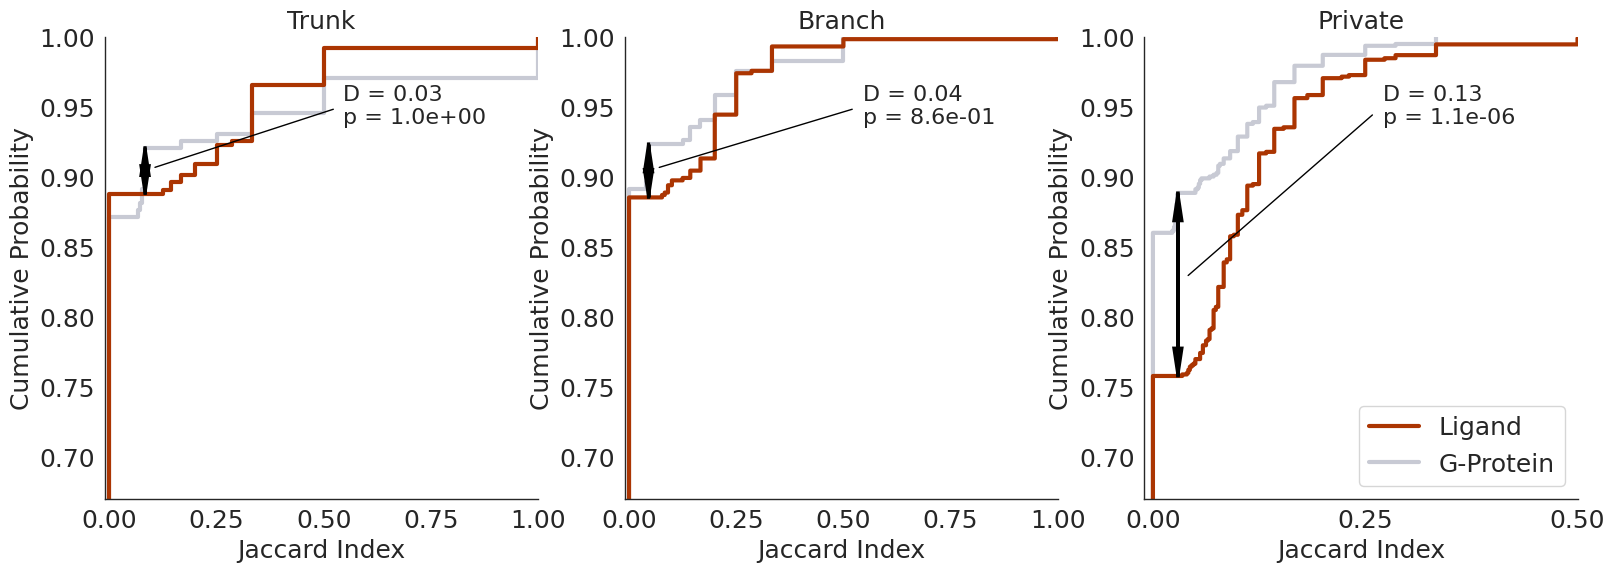

In [78]:
def plot_cdf_with_ks(data, condition, ax, color_ligand, color_gpcr):
    fs = 18

    # Set ylim and xlim based on condition
    ax.set_ylim(0.67, 1.)
    
    if condition == "Private":
        ax.set_xlim(-0.01, 0.5)
        arrow_width = 0.01  # half width
        ax.set_xticks([0, 0.25, 0.5])

    else:
        ax.set_xlim(-0.01, 1)
        arrow_width = 0.02  # default width
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1.00])

    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']
    
    # KS test
    ks_stat, p_value = ks_2samp(ligand_values, gpcr_values)

    # ECDF plots
    sns.ecdfplot(ligand_values, ax=ax, color=color_ligand, label='Ligand', linewidth=3, zorder=2)
    sns.ecdfplot(gpcr_values, ax=ax, color=color_gpcr, label='G-Protein', linewidth=3, zorder=1)

    # D-statistic logic
    cdf_ligand = np.sort(ligand_values)
    cdf_gpcr = np.sort(gpcr_values)
    all_values = np.sort(np.unique(np.concatenate((cdf_ligand, cdf_gpcr))))
    cdf_ligand_y = np.searchsorted(cdf_ligand, all_values, side='right') / len(cdf_ligand)
    cdf_gpcr_y = np.searchsorted(cdf_gpcr, all_values, side='right') / len(cdf_gpcr)
    max_diff_index = np.argmax(np.abs(cdf_ligand_y - cdf_gpcr_y))

    x_max_diff = all_values[max_diff_index]
    y1_max_diff = cdf_ligand_y[max_diff_index]
    y2_max_diff = cdf_gpcr_y[max_diff_index]
    midpoint_y = (y1_max_diff + y2_max_diff) / 2

    # Vertical D-statistic line and arrows
    ax.vlines(x_max_diff, y1_max_diff, y2_max_diff, color='k', linestyle='-', lw=2)
    ax.arrow(x_max_diff, y1_max_diff, 0, y2_max_diff - y1_max_diff, 
             color='k', linestyle='-', lw=2, head_width=arrow_width, head_length=0.02, length_includes_head=True, zorder=10)
    ax.arrow(x_max_diff, y2_max_diff, 0, y1_max_diff - y2_max_diff, 
             color='k', linestyle='-', lw=2, head_width=arrow_width, head_length=0.02, length_includes_head=True, zorder=10)

    # Annotation with KS stat
    text_object = ax.text(
        0.55, 0.85,
        f'D = {ks_stat:.2f}\np = {p_value:.1e}',
        fontsize=fs - 2, ha='left', va='center',
        transform=ax.transAxes,
    )

    text_x, text_y = text_object.get_position()
    max_diff_axis_rel = ax.transData.transform((x_max_diff, midpoint_y))
    max_diff_axis_rel_x, max_diff_axis_rel_y = ax.transAxes.inverted().transform(max_diff_axis_rel)

    direction_x = max_diff_axis_rel_x - text_x
    direction_y = max_diff_axis_rel_y - text_y

    offset_x = direction_x * 0.95
    offset_y = direction_y * 0.95

    start_x = text_x + offset_x
    start_y = text_y + offset_y
    end_x = max_diff_axis_rel_x - offset_x
    end_y = max_diff_axis_rel_y - offset_y

    ax.plot([start_x, end_x], [start_y, end_y], color='k', lw=1, linestyle='-', zorder=9, transform=ax.transAxes)

    # Axis labels and legend
    ax.set_title(f'{condition}', fontsize=fs)
    ax.set_xlabel('Jaccard Index', fontsize=fs)
    ax.set_ylabel('Cumulative Probability', fontsize=fs)
    ax.tick_params(labelsize=fs)
    ax.legend(fontsize=fs, loc='lower right')
    ax.grid(False)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Create a subplot mosaic with 1x3 grid layout
fig = plt.figure(figsize=(19, 6))

# Create the axes using the subplot mosaic
axes = fig.subplot_mosaic(
    """
    ABC
    """
)

# Plot for each condition
for i, condition in enumerate(df_jaccard['condition'].unique()):
    plot_cdf_with_ks(df_jaccard, condition, axes[chr(65 + i)], tcolor, lightgray)

# Remove legends from the first two axes
for ax in axes['A'], axes['B']:
    ax.legend_.remove()

# Save the figure
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/gpcrs/gpcrs_tumor_coevolution.png', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/gpcrs/gpcrs_tumor_coevolution.pdf', bbox_inches='tight', dpi=300)

# Show the plot
plt.show()

In [79]:
# Function to run the KS test and return the KS statistic and p-value
def get_pvals_stats(data, condition):
    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']

    # Perform KS test
    ks_stat, p_value = ks_2samp(ligand_values, gpcr_values)
    
    return ks_stat, p_value


In [87]:

def plot_cdf_with_ks(
    data,
    condition,
    ax,
    ks_stat,
    adjusted_p_value,
    color_ligand,
    color_gpcr, 
    ylim=None,
    xlim=None,    
    text_coords=(0.35, 0.85),
    text_ha='right',
):
    # Optionally set limits before plotting
    if ylim:
        ax.set_ylim(ylim)
    if xlim:
        ax.set_xlim(xlim)
        
    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']

    # Plot the ECDFs
    sns.ecdfplot(gpcr_values, ax=ax, color=color_gpcr, label='G-Protein', linewidth=3, zorder=1)
    sns.ecdfplot(ligand_values, ax=ax, color=color_ligand, label='Ligand', linewidth=3, zorder=2)

    # Highlight the maximum difference (D-statistic)
    cdf_ligand = np.sort(ligand_values)
    cdf_gpcr = np.sort(gpcr_values)
    all_values = np.sort(np.unique(np.concatenate((cdf_ligand, cdf_gpcr))))
    cdf_ligand_y = np.searchsorted(cdf_ligand, all_values, side='right') / len(cdf_ligand)
    cdf_gpcr_y = np.searchsorted(cdf_gpcr, all_values, side='right') / len(cdf_gpcr)
    max_diff_index = np.argmax(np.abs(cdf_ligand_y - cdf_gpcr_y))

    x_max_diff = all_values[max_diff_index]
    y1_max_diff = cdf_ligand_y[max_diff_index]
    y2_max_diff = cdf_gpcr_y[max_diff_index]
    midpoint_y = (y1_max_diff + y2_max_diff) / 2

    head_width  = 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])
    head_length = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])

    # D-statistic lines and arrows
    ax.vlines(x_max_diff, y1_max_diff, y2_max_diff, color='k', linestyle='-', lw=2)
    ax.arrow(x_max_diff, y1_max_diff, 0, y2_max_diff - y1_max_diff, 
             color='k', lw=2, head_width=head_width, head_length=head_length, length_includes_head=True, zorder=10)
    ax.arrow(x_max_diff, y2_max_diff, 0, y1_max_diff - y2_max_diff, 
             color='k', lw=2, head_width=head_width, head_length=head_length, length_includes_head=True, zorder=10)

    # Determine significance marker for p-value
    if adjusted_p_value < 0.001:
        significance = '***'
    elif adjusted_p_value < 0.01:
        significance = '**'
    elif adjusted_p_value < 0.05:
        significance = '*'
    else:
        significance = ''  # Not significant

    # D-statistic annotation with configurable position and alignment
    text_x, text_y = text_coords
    ax.text(
        text_x, text_y,
        f'D = {ks_stat:.2f}\np = {adjusted_p_value:.2e}\n{significance}',
        fontsize=fs, ha=text_ha, va='center',
        transform=ax.transAxes,
    )

    # Draw connector line to D-stat
    max_diff_axis_rel = ax.transData.transform((x_max_diff, midpoint_y))
    max_diff_axis_rel_x, max_diff_axis_rel_y = ax.transAxes.inverted().transform(max_diff_axis_rel)
    direction_x = max_diff_axis_rel_x - text_x
    direction_y = max_diff_axis_rel_y - text_y
    offset_x = direction_x * 0.85
    offset_y = direction_y * 0.85
    start_x = text_x + offset_x
    start_y = text_y + offset_y
    end_x = max_diff_axis_rel_x - offset_x
    end_y = max_diff_axis_rel_y - offset_y
    ax.plot([start_x, end_x], [start_y, end_y], color='k', lw=1, linestyle='-', zorder=9, transform=ax.transAxes)

    # Axes formatting
    ax.set_title(f'{condition}', fontsize=fs)
    ax.set_xlabel('Value', fontsize=fs)
    ax.set_ylabel('Cumulative Probability', fontsize=fs)
    ax.tick_params(labelsize=fs, direction='out')
    ax.legend(fontsize=fs, loc='lower right')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(bottom=True, left=True)  # Ensure ticks are visible
    ax.spines[['right', 'top']].set_visible(False)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    # Set ticks at a specific distance (e.g., 0.5 units)
    tick_distance = 0.5

    # Get the current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create tick positions based on the tick distance, starting from the lowest value within the limits
    x_ticks = np.arange(np.floor(xlim[0] / tick_distance) * tick_distance, 
                        np.ceil(xlim[1] / tick_distance) * tick_distance + tick_distance, 
                        tick_distance)
    y_ticks = np.arange(np.floor(ylim[0] / tick_distance) * tick_distance, 
                        np.ceil(ylim[1] / tick_distance) * tick_distance + tick_distance, 
                        tick_distance)

    # Filter ticks to ensure they are within the current axis limits
    x_ticks = x_ticks[(x_ticks >= xlim[0]) & (x_ticks <= xlim[1])]
    y_ticks = y_ticks[(y_ticks >= ylim[0]) & (y_ticks <= ylim[1])]

    # Apply the calculated ticks
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)



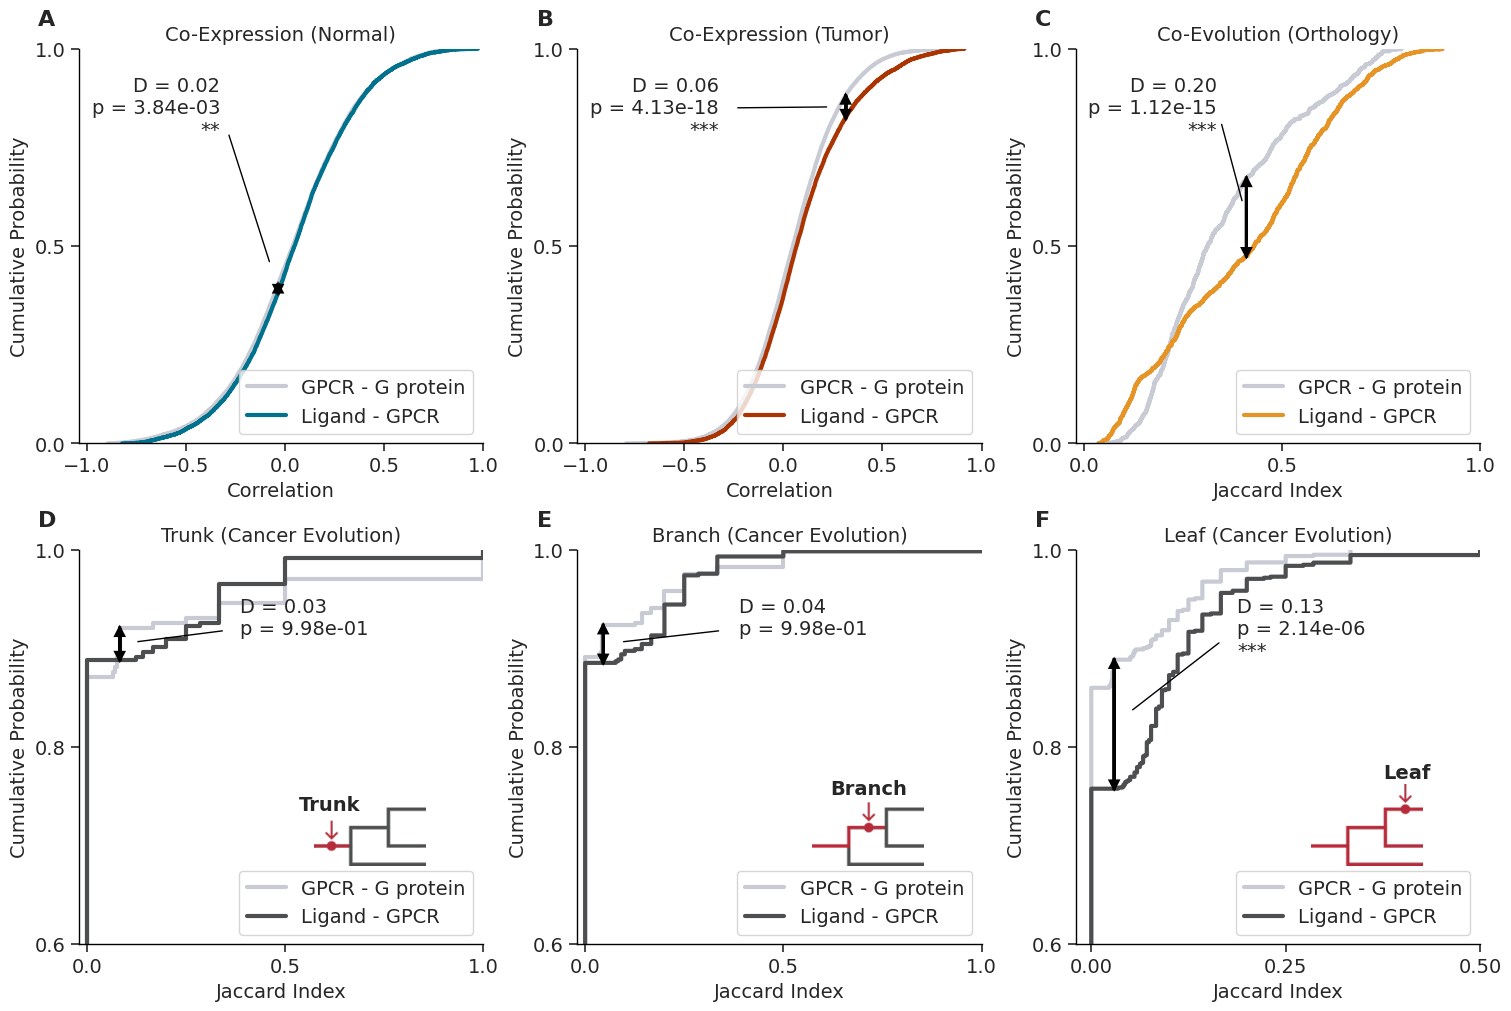

In [88]:
from scipy.stats import ks_2samp
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

fs = 14

# Create figure
fig, axes = plt.subplot_mosaic(
    mosaic="""
    ABC
    DEF
    """,
    figsize=(15, 10),
    constrained_layout=True
)

# Separate the conditions for df and df_jaccard
co_expression_conditions = ['Normal Co-Expression', 'Tumor Co-Expression', 'Coevolution']
jaccard_conditions = ['Trunk', 'Branch', 'Private']

ks_stats = []
p_vals = []

# Run KS test for co-expression conditions using df
for condition in co_expression_conditions:
    ks_stat, p_value = get_pvals_stats(df, condition)  # df for co-expression
    ks_stats.append(ks_stat)
    p_vals.append(p_value)

# Run KS test for Jaccard conditions using df_jaccard
for condition in jaccard_conditions:
    ks_stat, p_value = get_pvals_stats(df_jaccard, condition)  # df_jaccard for Jaccard indices
    ks_stats.append(ks_stat)
    p_vals.append(p_value)

# Apply FDR correction using false_discovery_control
corrected_pvals = false_discovery_control(p_vals)

# Co-expression plots — use defaults
plot_cdf_with_ks(df, 'Normal Co-Expression', axes['A'], ks_stats[0], corrected_pvals[0], ncolor, lightgray, xlim=(-1.04, 1))
plot_cdf_with_ks(df, 'Tumor Co-Expression', axes['B'], ks_stats[1], corrected_pvals[1], tcolor, lightgray, xlim=(-1.04, 1))
#plot_cdf_with_ks(df, 'Coevolution', axes['C'], ks_stats[2], corrected_pvals[2], orangecolor, lightgray, xlim=(-0.02, 1))
plot_cdf_with_ks(df, 'Coevolution', axes['C'], ks_stats[2], corrected_pvals[2], orangecolor, lightgray, xlim=(-0.02, 1))

# Jaccard plots — customize position and alignment
ylim_jaccard = (0.6, 1)
plot_cdf_with_ks(df_jaccard, 'Trunk'  , axes['D'], ks_stats[3], corrected_pvals[3], graycolor, lightgray, ylim=ylim_jaccard, xlim=(-0.02, 1), text_coords=(0.4, 0.8), text_ha='left')
plot_cdf_with_ks(df_jaccard, 'Branch' , axes['E'], ks_stats[4], corrected_pvals[4], graycolor, lightgray, ylim=ylim_jaccard, xlim=(-0.02, 1), text_coords=(0.4, 0.8), text_ha='left')
plot_cdf_with_ks(df_jaccard, 'Private', axes['F'], ks_stats[5], corrected_pvals[5], graycolor, lightgray, ylim=ylim_jaccard, xlim=(-0.02, 0.5), text_coords=(0.4, 0.8), text_ha='left')

# X-axis labels
axes['A'].set_xlabel('Correlation')
axes['B'].set_xlabel('Correlation')
axes['C'].set_xlabel('Jaccard Index')
axes['D'].set_xlabel('Jaccard Index')
axes['E'].set_xlabel('Jaccard Index')
axes['F'].set_xlabel('Jaccard Index')

# Titles
axes['A'].set_title('Co-Expression (Normal)', fontsize=fs)
axes['B'].set_title('Co-Expression (Tumor)', fontsize=fs)
axes['C'].set_title('Co-Evolution (Orthology)', fontsize=fs)
axes['D'].set_title('Trunk (Cancer Evolution)', fontsize=fs)
axes['E'].set_title('Branch (Cancer Evolution)', fontsize=fs)
axes['F'].set_title('Leaf (Cancer Evolution)', fontsize=fs)

axes['D'].set_xticks([0, 0.5, 1])
axes['E'].set_xticks([0, 0.5, 1])
axes['F'].set_xticks([0, 0.25, 0.5])

axes['D'].set_yticks([0.6, 0.8, 1])
axes['E'].set_yticks([0.6, 0.8, 1])
axes['F'].set_yticks([0.6, 0.8, 1])

icons_path = '/home/lnemati/pathway_crosstalk/data/coev_icons'

# === Icon controls ===
icon_scaling_factor = 0.25  # Adjust size of the icons

# === Add icons to panels D, E, and F ===
icon_files = {
    'D': 'trunk_reverse.png',
    'E': 'branch_reverse.png',
    'F': 'leaf_reverse.png',
}

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

for panel, icon_name in icon_files.items():
    icon_path = os.path.join(icons_path, icon_name)
    if os.path.exists(icon_path):
        # Load and resize icon
        icon = Image.open(icon_path)
        width, height = icon.size
        icon_resized = icon.resize((int(width * icon_scaling_factor), int(height * icon_scaling_factor)))
        icon_array = np.array(icon_resized)

        # Create image box
        imagebox = OffsetImage(icon_array, zoom=0.5, resample=True)

        # Position in axes-relative coordinates (x=0.78, y=0.28 is consistent)
        ab = AnnotationBbox(
            imagebox,
            (0.72, 0.3),           # Position of the icon
            xycoords='axes fraction',
            frameon=False
        )

        axes[panel].add_artist(ab)

        # === Add label text above the icon ===
        label_map = {'D': 'Trunk', 'E': 'Branch', 'F': 'Leaf'}
        offsetx = {'D': -0.1,'E': 0, 'F': 0.1}
        offsety = {'D': -0.04,'E': 0, 'F': 0.04}
        axes[panel].text(
            0.72 + offsetx[panel],
            0.37 + offsety[panel],
            label_map[panel],
            transform=axes[panel].transAxes,
            ha='center',
            va='bottom',
            fontsize=fs,
            fontweight='bold'
        )

for ax in axes.values():
    ax.tick_params(length=6, width=1.2)

# === Add panel letters ===
panel_labels = ['A', 'B', 'C', 'D', 'E', 'F']
for label, ax in zip(panel_labels, axes.values()):
    ax.text(
        -0.1, 1.1,  # Top-left corner in axes coords
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='left'
    )
    

# In the legend replace 'G-Protein' with 'GPCR-Gprotein' and 'Ligand' with 'Ligand-GPCR'
for ax in axes.values():
    handles, labels = ax.get_legend_handles_labels()
    new_labels = []
    for label in labels:
        if label == 'G-Protein':
            new_labels.append('GPCR - G protein')
        elif label == 'Ligand':
            new_labels.append('Ligand - GPCR')
        else:
            new_labels.append(label)
    ax.legend(handles, new_labels, fontsize=fs, loc='lower right')

os.makedirs('/home/lnemati/pathway_crosstalk/results/figures/appeal/fig2', exist_ok=True)
plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/appeal/fig2/fig2.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/appeal/fig2/fig2.svg', bbox_inches='tight', dpi=300)
plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/appeal/fig2/fig2.png', bbox_inches='tight', dpi=300)

plt.show()


In [53]:
fig_to_panels(fig, axes, output_dir='/home/lnemati/pathway_crosstalk/results/figures/appeal/fig2/panels')

Saved panel 'Co-Expression (Normal)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/co-expression_(normal)
Saved panel 'Co-Expression (Tumor)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/co-expression_(tumor)
Saved panel 'Co-Evolution (Orthology)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/co-evolution_(orthology)
Saved panel 'Trunk (Cancer Evolution)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/trunk_(cancer_evolution)
Saved panel 'Branch (Cancer Evolution)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/branch_(cancer_evolution)
Saved panel 'Leaf (Cancer Evolution)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/leaf_(cancer_evolution)


# Partial Corr all TCGA and GTEx

In [2]:
from scanpy import read_h5ad
from ast import literal_eval
import numpy as np
import pandas as pd
#from pydeseq2.dds import DeseqDataSet, DefaultInference
import pingouin as pg
#from sklearn.covariance import LedoitWolf


In [8]:
from pathlib import Path
import os

parent_dir = Path('/projects/bioinformatics/DB/Xena/TCGA_GTEX/')

tcga_paths = []
gtex_paths = []

print("🔍 Scanning for .h5ad files...")

for root, dirs, files in os.walk(parent_dir):
    for file in files:
        if not file.endswith(".h5ad"):
            continue
        full_path = Path(root) / file
        path_str = str(full_path).lower()  # case-insensitive

        # Only check if '/tumor/' or '/normal/' exists in the path
        if "/tumor/" in path_str:
            tcga_paths.append(full_path)
        elif "/normal/" in path_str:
            gtex_paths.append(full_path)

# Remove duplicates just in case
tcga_paths = list(set(tcga_paths))
gtex_paths = list(set(gtex_paths))

print(f"✅ Found {len(tcga_paths)} TCGA files")
print(f"✅ Found {len(gtex_paths)} GTEx files")

🔍 Scanning for .h5ad files...
✅ Found 64 TCGA files
✅ Found 94 GTEx files


In [10]:
import os
from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np
from scanpy.pp import scale

parent_dir = Path('/projects/bioinformatics/DB/Xena/TCGA_GTEX/by_tissue_primary_vs_normal')

tcga_paths = []
gtex_paths = []

print("🔍 Scanning for .h5ad files...")

for root, dirs, files in os.walk(parent_dir):
    for file in files:
        if file.endswith(".h5ad"):
            full_path = Path(root) / file
            grandparent = full_path.parent.parent.name.lower()  # grandparent folder
            if grandparent == "tumor":
                tcga_paths.append(full_path)
            elif grandparent == "normal":
                gtex_paths.append(full_path)
                
print(f"✅ Found {len(tcga_paths)} TCGA files")
print(f"✅ Found {len(gtex_paths)} GTEx files")


def load_and_concat(paths, label="dataset"):
    adatas = []
    gene_sets = []

    print(f"\n📂 Opening {len(paths)} {label} files in backed mode...")

    # Open all in backed mode and collect gene sets
    for i, p in enumerate(paths, 1):
        print(f"[{label}] Loading gene list {i}/{len(paths)}: {p.name}")
        adata = sc.read_h5ad(p, backed="r")
        
        adatas.append(adata)
        gene_sets.append(set(adata.var_names))
        
    # Keep only genes present in ALL datasets
    print(f"[{label}] Computing gene intersection...")
    common_genes = sorted(set.intersection(*gene_sets))
    print(f"[{label}] Keeping {len(common_genes)} common genes")

    expression_list = []
    metadata_list = []

    print(f"[{label}] Reading expression matrices...")
    
    for i, adata in enumerate(adatas, 1):
        print(f"[{label}] Processing file {i}/{len(adatas)} "
              f"({adata.n_obs} samples)")
        
        
        X = adata[:, common_genes].X
        
        X = X.astype(np.float32, copy=False)
        
        mean = X.mean(axis=0)
        std = X.std(axis=0)
        std[std == 0] = 1
        X = (X - mean) / std
        
        expression_list.append(
            pd.DataFrame(X, columns=common_genes, index=adata.obs_names)
        )
        metadata_list.append(adata.obs.copy())

        adata.file.close()

    print(f"[{label}] Concatenating matrices...")
    expression_df = pd.concat(expression_list, axis=0)
    metadata_df = pd.concat(metadata_list, axis=0)

    print(f"[{label}] Done. Final shape: {expression_df.shape}")

    return expression_df, metadata_df


print("\n🚀 Building TCGA dataset...")
tcga_expression, tcga_metadata = load_and_concat(tcga_paths, label="TCGA")

print("\n🚀 Building GTEx dataset...")
gtex_expression, gtex_metadata = load_and_concat(gtex_paths, label="GTEx")


print("\n🧬 Creating AnnData objects...")

tcga = sc.AnnData(
    X=tcga_expression.values,
    obs=tcga_metadata,
    var=pd.DataFrame(index=tcga_expression.columns)
)

gtex = sc.AnnData(
    X=gtex_expression.values,
    obs=gtex_metadata,
    var=pd.DataFrame(index=gtex_expression.columns)
)

print('done')

🔍 Scanning for .h5ad files...
✅ Found 32 TCGA files
✅ Found 46 GTEx files

🚀 Building TCGA dataset...

📂 Opening 32 TCGA files in backed mode...
[TCGA] Loading gene list 1/32: rectum_adenocarcinoma.h5ad
[TCGA] Loading gene list 2/32: uterine_carcinosarcoma.h5ad
[TCGA] Loading gene list 3/32: kidney_papillary_cell_carcinoma.h5ad
[TCGA] Loading gene list 4/32: kidney_chromophobe.h5ad
[TCGA] Loading gene list 5/32: kidney_clear_cell_carcinoma.h5ad
[TCGA] Loading gene list 6/32: brain_lower_grade_glioma.h5ad
[TCGA] Loading gene list 7/32: glioblastoma_multiforme.h5ad
[TCGA] Loading gene list 8/32: adrenocortical_cancer.h5ad
[TCGA] Loading gene list 9/32: testicular_germ_cell_tumor.h5ad
[TCGA] Loading gene list 10/32: liver_hepatocellular_carcinoma.h5ad
[TCGA] Loading gene list 11/32: prostate_adenocarcinoma.h5ad
[TCGA] Loading gene list 12/32: thymoma.h5ad
[TCGA] Loading gene list 13/32: lung_squamous_cell_carcinoma.h5ad
[TCGA] Loading gene list 14/32: lung_adenocarcinoma.h5ad
[TCGA] Loadi

In [11]:
import anndata
anndata.settings.allow_write_nullable_strings = True

gtex.write('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex_scaled.h5ad')
tcga.write('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga_scaled.h5ad')

In [3]:
gtex = read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex_scaled.h5ad')
tcga = read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga_scaled.h5ad')

In [4]:
#del gtex.layers['deseq2_norm_counts']
#del gtex.layers['deseq2_vst_counts']
#del gtex.layers['raw_counts']
#del gtex.layers['TPM']
#
#del tcga.layers['deseq2_norm_counts']
#del tcga.layers['deseq2_vst_counts']
#del tcga.layers['raw_counts']
#del tcga.layers['TPM']

In [12]:
import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import mannwhitneyu
from ast import literal_eval
import os

def run_interaction_analysis(
    adatas,
    interaction_file,
    dataset_prefix=None,
    save_adata=False,
    save_corr=False,
    load_corr=False,
    save_plot=False,
    use_common_genes=False
):
    """
    Perform correlation/partial correlation analysis and AUROC evaluation
    for ligand-receptor or other interaction pairs.
    
    Parameters
    ----------
    adatas : dict
        Dictionary of AnnData objects, e.g., {'gtex': gtex, 'tcga': tcga}
    interaction_file : str
        CSV file with ligand-receptor or interaction pairs. Must have 'all_genes' column
    dataset_prefix : str or None
        Optional prefix for saving files (e.g., 'ccc')
    save_adata : bool
        If True, saves subsetted AnnData objects
    save_corr : bool
        If True, save correlation matrices
    load_corr : bool
        If True, attempt to load previously saved correlation matrices
    save_plot : bool
        If True, saves ROC plot as PNG
    use_common_genes : bool
        If True, subsets matrices to genes present in all datasets
    """
    
    save_dir = "/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex"
    dataset_name = dataset_prefix if dataset_prefix else "dataset"
    print(f"\n=== Processing interactions: {interaction_file} ===")
    
    # --- Load interactions and extract genes ---
    interactions = pd.read_csv(interaction_file)
    interactions['all_genes'] = interactions['all_genes'].apply(literal_eval)
    genes = interactions['all_genes'].explode().unique()
    
    # --- Subset AnnData to interaction genes ---
    adata_dict = {}
    for name, adata in adatas.items():
        # SUBSET TO CCC GENES
        adata_sub = adata[:, adata.var_names.isin(genes)].copy()
        adata_dict[name] = adata_sub
        print(f"{name}: {adata.n_vars} -> {adata_sub.n_vars} genes after subsetting")
        if save_adata:
            adata_sub.write_h5ad(f"{save_dir}/{name}_{dataset_name}.h5ad")
            print(f"Saved subset AnnData: {name}_{dataset_name}.h5ad")
        
        # USE ALL GENES
        #adata_dict[name] = adata

    # --- Compute or load correlations ---
    matrices = {}
    for name, adata in adata_dict.items():
        corr_file = f"{save_dir}/{name}_{dataset_name}_corr.csv.gz"
        pcorr_file = f"{save_dir}/{name}_{dataset_name}_pcorr.csv.gz"
        
        if load_corr and os.path.exists(corr_file) and os.path.exists(pcorr_file):
            print(f"Loading saved correlation matrices for {name}")
            corr = pd.read_csv(corr_file, index_col=0)
            pcorr = pd.read_csv(pcorr_file, index_col=0)
        else:
            print(f"Computing correlation matrices for {name}")
            geneExp = pd.DataFrame(
                adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X,
                columns=adata.var_names
            )
            corr = geneExp.corr()
            pcorr = pg.pcorr(geneExp)
            if save_corr:
                corr.to_csv(corr_file, compression="gzip")
                pcorr.to_csv(pcorr_file, compression="gzip")
                print(f"Saved correlation matrices for {name}")
        
        matrices[name] = {"corr": corr, "pcorr": pcorr}
    
    # --- Optional: filter to common genes ---
    common_genes = None
    if use_common_genes:
        common_genes = set.intersection(*(set(matrices[n]['corr'].index) for n in matrices))
        print(f"Common genes across datasets: {len(common_genes)}")
    
    # --- Prepare interaction pairs ---
    interactions['interactor1'] = interactions['all_genes'].apply(lambda x: x[0])
    interactions['interactor2'] = interactions['all_genes'].apply(lambda x: x[1])
    int_pairs = set(zip(interactions.interactor1, interactions.interactor2))
    
    # --- Compute AUROC and plot ROC ---
    results = []
    plt.figure(figsize=(8,6))
    colors = {"gtex": '#00728eff', "tcga": '#ab3502ff'}
    linestyles = {"corr": "solid", "pcorr": "dashed"}
    
    for dataset_name in matrices:
        print(f"\nDataset: {dataset_name}")
        for corr_type in ["corr", "pcorr"]:
            print(f"  Correlation type: {corr_type}")
            mat = matrices[dataset_name][corr_type]
            if common_genes:
                mat = mat.loc[common_genes, common_genes]
            
            genes_set = set(mat.index)
            valid_pairs = {(l,r) for l,r in int_pairs if l in genes_set and r in genes_set and l != r}
            
            # Flatten lower triangle
            pairs = pd.DataFrame(mat.where(np.tri(mat.shape[0], k=-1, dtype=bool)).stack(), columns=["value"]).dropna()
            pairs["interaction"] = [1 if (g1,g2) in valid_pairs or (g2,g1) in valid_pairs else 0 for g1,g2 in pairs.index]
            
            interacting = pairs.loc[pairs.interaction==1, "value"]
            non_interacting = pairs.loc[pairs.interaction==0, "value"]
            
            if pairs["interaction"].nunique() < 2:
                auroc, U, p = np.nan, np.nan, np.nan
                fpr, tpr = [0,1], [0,1]
                print("    Not enough interaction types to compute AUROC")
            else:
                auroc = roc_auc_score(pairs["interaction"], pairs["value"])
                U, p = mannwhitneyu(interacting, non_interacting, alternative="greater")
                fpr, tpr, _ = roc_curve(pairs["interaction"], pairs["value"])
                print(f"    AUROC: {auroc:.3f}, Mann-Whitney p: {p:.3g}")
            
            results.append({
                "dataset": dataset_name,
                "type": corr_type,
                "auroc": auroc,
                "mannwhitney_U": U,
                "mannwhitney_p": p
            })
            
            # Plot ROC
            plt.plot(fpr, tpr, label=f"{dataset_name}-{corr_type} (AUROC={auroc:.2f})",
                     color=colors.get(dataset_name, "black"), linestyle=linestyles[corr_type], linewidth=2)
    
    plt.plot([0,1],[0,1], color="gray", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves: {dataset_prefix if dataset_prefix else 'Interactions'}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_plot:
        plt.savefig(f"{save_dir}/{dataset_prefix}_roc.png", dpi=150)
        print(f"ROC plot saved as {dataset_prefix}_roc.png")
    plt.show()
    
    results_df = pd.DataFrame(results).sort_values(["dataset","type"])
    return matrices, results_df


=== Processing interactions: /home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv ===
gtex: 9949 -> 369 genes after subsetting
tcga: 11311 -> 531 genes after subsetting
Computing correlation matrices for gtex
Saved correlation matrices for gtex
Computing correlation matrices for tcga
Saved correlation matrices for tcga

Dataset: gtex
  Correlation type: corr
    AUROC: 0.631, Mann-Whitney p: 3.65e-16
  Correlation type: pcorr
    AUROC: 0.527, Mann-Whitney p: 0.0464

Dataset: tcga
  Correlation type: corr
    AUROC: 0.677, Mann-Whitney p: 6.66e-51
  Correlation type: pcorr
    AUROC: 0.559, Mann-Whitney p: 3.13e-07
ROC plot saved as ccc_lr_pairs_roc.png


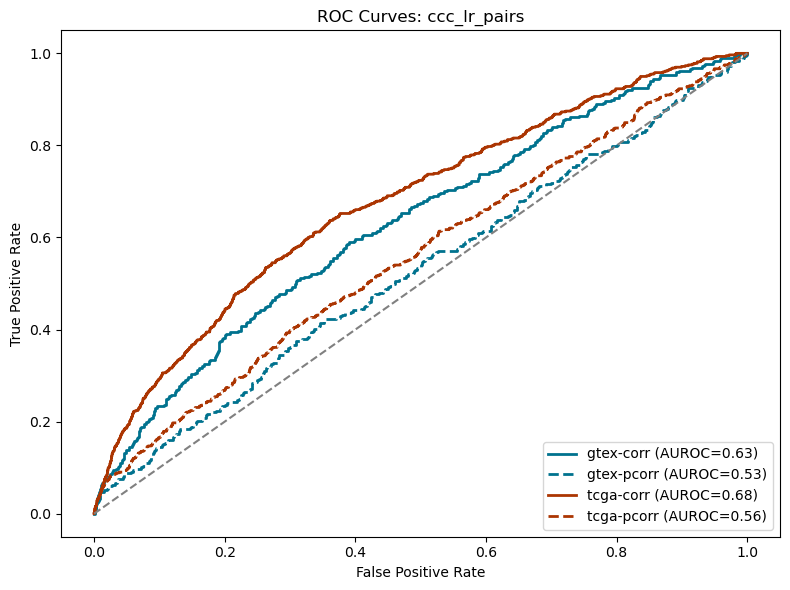


=== Processing interactions: /home/lnemati/pathway_crosstalk/data/interactions/intact_direct.csv ===
gtex: 9949 -> 3027 genes after subsetting
tcga: 11311 -> 3354 genes after subsetting
Computing correlation matrices for gtex
Saved correlation matrices for gtex
Computing correlation matrices for tcga
Saved correlation matrices for tcga

Dataset: gtex
  Correlation type: corr
    AUROC: 0.580, Mann-Whitney p: 1.4e-78
  Correlation type: pcorr
    AUROC: 0.526, Mann-Whitney p: 9.79e-10

Dataset: tcga
  Correlation type: corr
    AUROC: 0.585, Mann-Whitney p: 1.29e-106
  Correlation type: pcorr
    AUROC: 0.533, Mann-Whitney p: 2.46e-17
ROC plot saved as intact_direct_roc.png


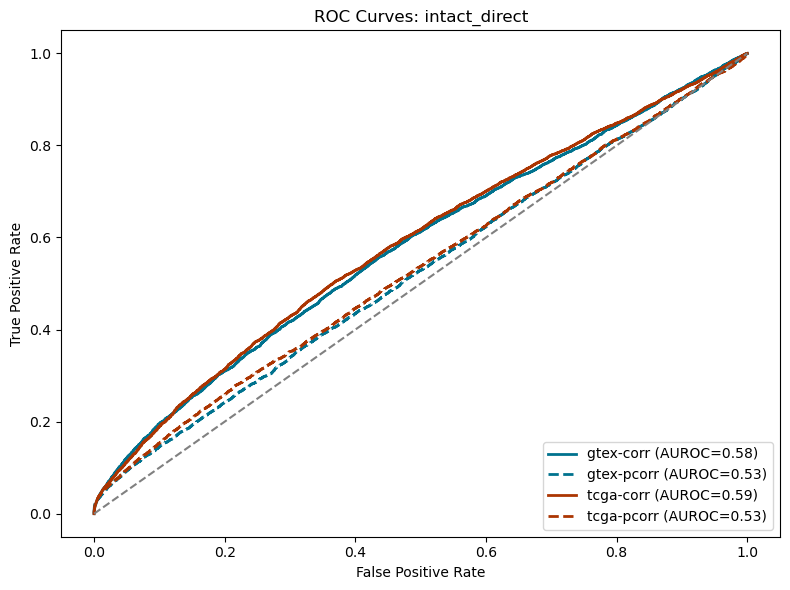


=== Processing interactions: /home/lnemati/pathway_crosstalk/data/interactions/intact_physical.csv ===
gtex: 9949 -> 9066 genes after subsetting
tcga: 11311 -> 10180 genes after subsetting
Computing correlation matrices for gtex
Saved correlation matrices for gtex
Computing correlation matrices for tcga
Saved correlation matrices for tcga

Dataset: gtex
  Correlation type: corr
    AUROC: 0.556, Mann-Whitney p: 0
  Correlation type: pcorr
    AUROC: 0.502, Mann-Whitney p: 0.0252

Dataset: tcga
  Correlation type: corr
    AUROC: 0.553, Mann-Whitney p: 0
  Correlation type: pcorr
    AUROC: 0.500, Mann-Whitney p: 0.55
ROC plot saved as intact_physical_roc.png


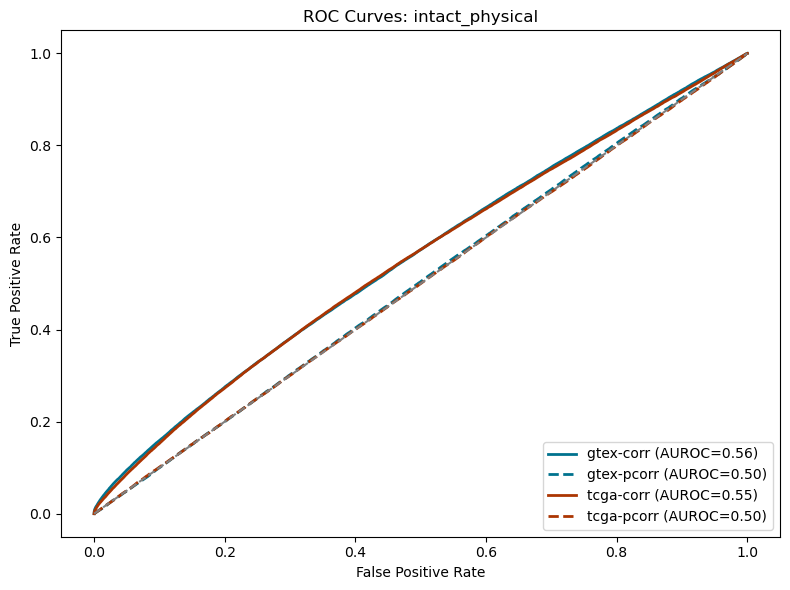


=== Processing interactions: /home/lnemati/pathway_crosstalk/data/interactions/intact_association.csv ===
gtex: 9949 -> 9302 genes after subsetting
tcga: 11311 -> 10442 genes after subsetting
Computing correlation matrices for gtex
Saved correlation matrices for gtex
Computing correlation matrices for tcga
Saved correlation matrices for tcga

Dataset: gtex
  Correlation type: corr
    AUROC: 0.571, Mann-Whitney p: 0
  Correlation type: pcorr
    AUROC: 0.501, Mann-Whitney p: 0.0203

Dataset: tcga
  Correlation type: corr
    AUROC: 0.562, Mann-Whitney p: 0
  Correlation type: pcorr
    AUROC: 0.500, Mann-Whitney p: 0.385
ROC plot saved as intact_association_roc.png


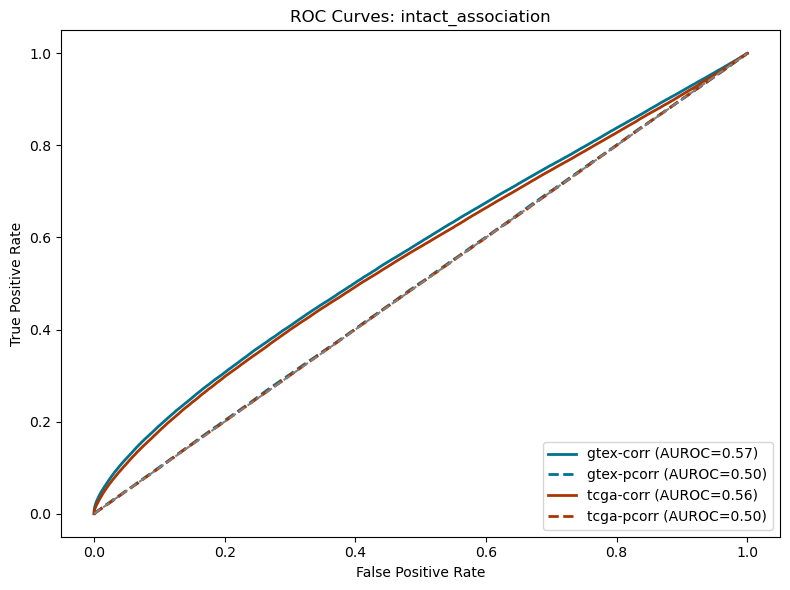

In [13]:
adatas = {"gtex": gtex, "tcga": tcga}
interaction_files = [
    "/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv",
    "/home/lnemati/pathway_crosstalk/data/interactions/intact_direct.csv",
    "/home/lnemati/pathway_crosstalk/data/interactions/intact_physical.csv",
    "/home/lnemati/pathway_crosstalk/data/interactions/intact_association.csv",
]

all_results = []

for f in interaction_files:
    prefix = f.split("/")[-1].replace(".csv","")
    matrices, results_df = run_interaction_analysis(
        adatas,
        interaction_file=f,
        dataset_prefix=prefix,
        save_adata=False,
        save_corr=True,
        load_corr=False,
        save_plot=True,
        use_common_genes=False
    )
    results_df['interaction_file'] = prefix
    all_results.append(results_df)

all_results_df = pd.concat(all_results).reset_index(drop=True)
all_results_df.to_csv("/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/aurocs_ccis_intact.csv")

In [14]:
all_results_df

,dataset,type,auroc,mannwhitney_U,mannwhitney_p,interaction_file
0,gtex,corr,0.631076,1.351925e+07,3.650979e-16,ccc_lr_pairs
1,gtex,pcorr,0.527324,1.129663e+07,4.635113e-02,ccc_lr_pairs
2,tcga,corr,0.676981,5.672424e+07,6.664835e-51,ccc_lr_pairs
3,tcga,pcorr,0.558946,4.683403e+07,3.134907e-07,ccc_lr_pairs
4,gtex,corr,0.579962,1.214499e+10,1.400268e-78,intact_direct
5,gtex,pcorr,0.525620,1.100703e+10,9.785964e-10,intact_direct
6,tcga,corr,0.585413,1.803443e+10,1.291583e-106,intact_direct
7,tcga,pcorr,0.532716,1.641105e+10,2.458537e-17,intact_direct
8,gtex,corr,0.555536,1.264258e+12,0.000000e+00,intact_physical
9,gtex,pcorr,0.502401,1.143335e+12,2.517283e-02,intact_physical


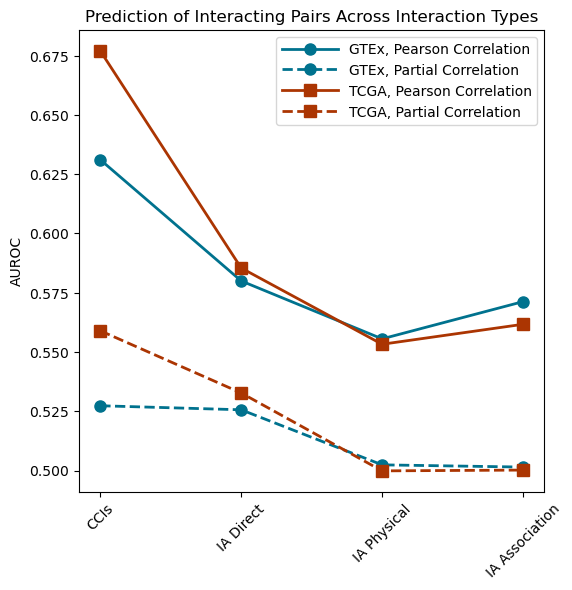

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure correct file order
file_order = [
    "ccc_lr_pairs",
    "intact_direct",
    "intact_physical",
    "intact_association"
]

df = all_results_df.copy()
df["interaction_file"] = pd.Categorical(
    df["interaction_file"],
    categories=file_order,
    ordered=True
)
df = df.sort_values("interaction_file")

# Color scheme
colors = {"tcga": "#ab3502ff", "gtex": "#00728eff"}

# Marker and linestyle mapping
markers = {"tcga": "s", "gtex": "o"}
linestyles = {"corr": "solid", "pcorr": "dashed"}

plt.figure(figsize=(6, 6))

for dataset in df["dataset"].unique():
    for corr_type in ["corr", "pcorr"]:
        subset = df[(df["dataset"] == dataset) & (df["type"] == corr_type)]
        
        dataset_label = dataset.replace('tcga', 'TCGA').replace('gtex', 'GTEx')
        corr_label = corr_type.replace('pcorr', 'Partial Correlation').replace('corr', 'Pearson Correlation')
        
        plt.plot(
            subset["interaction_file"],
            subset["auroc"],
            marker=markers[dataset],
            linestyle=linestyles[corr_type],
            color=colors[dataset],
            linewidth=2,
            markersize=8,
            label=f"{dataset_label}, {corr_label}"
        )

plt.xlabel("")
plt.ylabel("AUROC")
plt.title("Prediction of Interacting Pairs Across Interaction Types")
plt.xticks(
    ticks=range(len(file_order)),
    labels=['CCIs', 'IA Direct', 'IA Physical', 'IA Association'],
    rotation=45
)
plt.legend(handlelength=4)

plt.savefig("/home/lnemati/pathway_crosstalk/results/comparison/pcorr_aurocs_ccis_intact.png", bbox_inches='tight', dpi=300)
plt.savefig("/home/lnemati/pathway_crosstalk/results/comparison/pcorr_aurocs_ccis_intact.pdf", bbox_inches='tight', dpi=300)

plt.show()

In [14]:
all_results_df.sort_values(by='auroc')

,dataset,type,n_genes,n_pairs,n_interacting,median_interacting,median_non_interacting,auroc,mannwhitney_U,mannwhitney_p,interaction_file
1,gtex,pcorr,4414,9739491,7785,0.002033,0.000116,0.527295,3.994855e+10,3.739344e-17,intact_direct
3,tcga,pcorr,4414,9739491,7785,0.001624,0.000024,0.527663,3.997647e+10,1.434409e-17,intact_direct
5,gtex,pcorr,474,112101,499,0.004489,0.000239,0.543265,3.025409e+07,4.182107e-04,ccc_lr_pairs
7,tcga,pcorr,474,112101,499,0.004130,0.000421,0.546484,3.043334e+07,1.659957e-04,ccc_lr_pairs
0,gtex,corr,4414,9739491,7785,0.075735,-0.006949,0.586797,4.445651e+10,2.961038e-155,intact_direct
2,tcga,corr,4414,9739491,7785,0.060827,-0.000974,0.593927,4.499674e+10,2.069695e-181,intact_direct
6,tcga,corr,474,112101,499,0.142464,0.033816,0.627024,3.491860e+07,5.228206e-23,ccc_lr_pairs
4,gtex,corr,474,112101,499,0.157477,0.007589,0.636399,3.544068e+07,3.098955e-26,ccc_lr_pairs


In [37]:
gtex = sc.read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex_ccc_genes_only.h5ad')
tcga = sc.read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga_ccc_genes_only.h5ad')

In [8]:
#tcga.X = tcga.layers['deseq2_vst_counts']
#gtex.X = gtex.layers['deseq2_vst_counts']

Computed correlation matrices for gtex
Computed correlation matrices for tcga


In [1]:
import scanpy as sc
from ast import literal_eval
import numpy as np
import pandas as pd
from pydeseq2.dds import DeseqDataSet, DefaultInference
import pingouin as pg
from sklearn.covariance import LedoitWolf

In [2]:
gtex = sc.read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex.h5ad')
tcga = sc.read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga.h5ad')

In [ ]:
import pandas as pd

# adata objects
adata_dict = {'gtex': gtex, 'tcga': tcga}

# Interaction files to analyze
interaction_files = [
    "/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv",
    "/home/lnemati/pathway_crosstalk/data/interactions/intact_direct.csv"
]

all_results = []

for f in interaction_files:
    print(f"\nProcessing interactions: {f}")
    matrices, results_df = analyze_interactions(
        adata_dict,
        interaction_file=f,
        save_subsets=False,
        save_corr_dir="/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex",
        use_common_genes=False
    )
    results_df['interaction_file'] = f.split('/')[-1]
    all_results.append(results_df)

# Combine all results into a single DataFrame
combined_results = pd.concat(all_results, ignore_index=True)
combined_results.sort_values(['interaction_file','dataset','type'], inplace=True)

# Show combined AUROC table
combined_results


Processing interactions: /home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv

=== Loading interactions from /home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv ===
Number of interaction pairs: 3748

=== Computing correlation matrices ===
Processing dataset: gtex
  Number of genes in dataset: 19013
  Computing Pearson correlation...


In [4]:
def run_deseq2_normalization(adata, n_cpus=1, condition_key="condition"):
    """
    Perform DESeq2 normalization and VST on an AnnData object.

    Parameters
    ----------
    adata : AnnData
        AnnData object containing raw counts in `adata.layers["raw_counts"]`
    n_cpus : int, optional
        Number of CPUs for DESeq2 inference (default = 1)
    condition_key : str, optional
        Column in adata.obs used as design factor (default = "condition")

    Returns
    -------
    AnnData
        Updated AnnData with:
        - adata.layers["deseq2_norm_counts"]
        - adata.layers["deseq2_vst_counts"]
        - adata.X set to normalized counts
    """

    print("Starting DESeq2 normalization")

    # Load raw counts into X
    adata.X = adata.layers["raw_counts"].todense()

    # Determine design factor
    if condition_key in adata.obs and len(adata.obs[condition_key].unique()) > 1:
        design_factors = condition_key
    else:
        print("Cannot run DESeq2 on a single condition, creating dummy design factors")
        adata.obs["dummy_deseq2_condition"] = [
            "A" if i % 2 == 0 else "B" for i in range(len(adata.obs))
        ]
        design_factors = "dummy_deseq2_condition"

    print("Initializing DESeq2")
    inference = DefaultInference(n_cpus=n_cpus)

    dds = DeseqDataSet(
        counts=pd.DataFrame(
            data=adata.X.astype(int),
            index=adata.obs_names,
            columns=adata.var_names,
        ),
        metadata=adata.obs,
        design_factors=design_factors,
        refit_cooks=True,
        inference=inference,
    )

    print("Running DESeq2 normalization")
    dds.fit_size_factors()

    # Store normalized counts
    adata.layers["deseq2_norm_counts"] = dds.layers["normed_counts"].copy()
    adata.X = adata.layers["deseq2_norm_counts"].copy()

    print("Variance stabilizing transformation")
    dds.vst(use_design=False)
    adata.layers["deseq2_vst_counts"] = dds.layers["vst_counts"].copy()

    # Remove dummy factor if created
    if design_factors == "dummy_deseq2_condition":
        adata.obs.drop(columns=design_factors, inplace=True)

    adata.X = adata.layers["deseq2_vst_counts"].copy()
    print("DESeq2 normalization complete")

    return adata

In [5]:
gtex = run_deseq2_normalization(gtex, n_cpus=16)
tcga = run_deseq2_normalization(tcga, n_cpus=16)

Starting DESeq2 normalization


/var/tmp/pbs.415445.pbs01/ipykernel_23086/2205115722.py:26: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  adata.X = adata.layers["raw_counts"].todense()


Initializing DESeq2


/var/tmp/pbs.415445.pbs01/ipykernel_23086/2205115722.py:41: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(


Running DESeq2 normalization
Using None as control genes, passed at DeseqDataSet initialization


...

Running DESeq2 normalization
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 19.47 seconds.



Variance stabilizing transformation
Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 19.49 seconds.

Fitting dispersions...
... done in 37.82 seconds.



DESeq2 normalization complete


In [9]:
import anndata
anndata.settings.allow_write_nullable_strings = True

#gtex.write('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex.h5ad')
#tcga.write('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga.h5ad')

In [36]:
ccc = pd.read_csv("/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv")
# Eval all_genes as a list
ccc['all_genes'] = ccc['all_genes'].apply(literal_eval)
# get set of all genes in ccc
ccc_genes = ccc['all_genes'].explode().unique()

# Subset to ccc genes
gtex = gtex[:, gtex.var_names.isin(ccc_genes)]
tcga = tcga[:, tcga.var_names.isin(ccc_genes)]

# Save
gtex.write_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex_ccc_genes_only.h5ad')
tcga.write_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga_ccc_genes_only.h5ad')

NameError: name 'ccc_genes' is not defined

In [37]:
gtex = sc.read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex_ccc_genes_only.h5ad')
tcga = sc.read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga_ccc_genes_only.h5ad')

In [8]:
#tcga.X = tcga.layers['deseq2_vst_counts']
#gtex.X = gtex.layers['deseq2_vst_counts']

In [38]:
import pandas as pd
import pingouin as pg  # for partial correlation

# -------------------------
# CORRELATION MATRICES
# -------------------------
for adata, name in [(gtex, "gtex"), (tcga, "tcga")]:
    # Convert AnnData X to DataFrame
    geneExp = pd.DataFrame(
        adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X,
        columns=adata.var_names
    )

    # 1. Pearson correlation
    corr = geneExp.corr(method="pearson")

    # 2. Partial correlation
    pcorr = pg.pcorr(geneExp)

    # Store all matrices in a dictionary
    globals()[f"{name}_matrices"] = {
        "corr": corr,
        "pcorr": pcorr,
    }

    corr.to_csv(f'/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/{name}_corr_ccc_genes_only.csv.gz')
    pcorr.to_csv(f'/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/{name}_pcorr_ccc_genes_only.csv.gz')

    print(f"Computed correlation matrices for {name}")

Computed correlation matrices for gtex
Computed correlation matrices for tcga


gtex
corr
pcorr
tcga
corr
pcorr


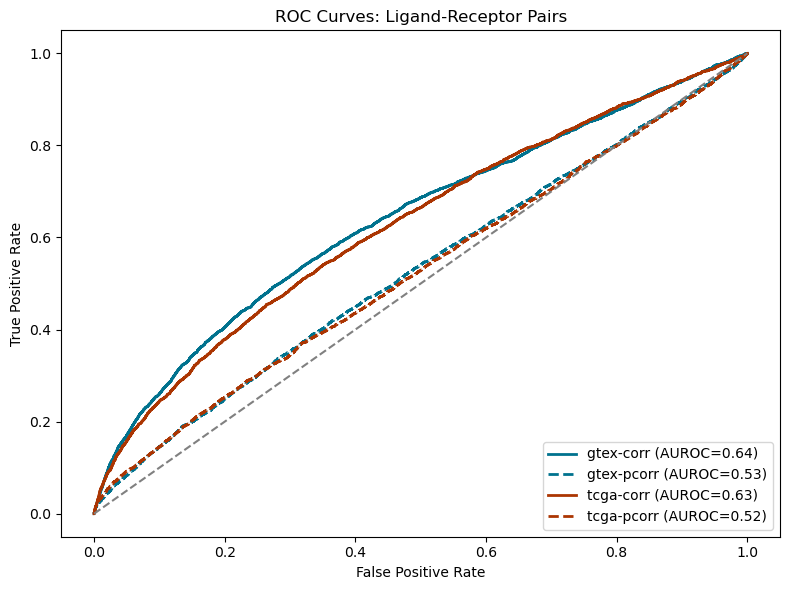

,dataset,type,n_genes,n_pairs,n_interacting,median_interacting,median_non_interacting,auroc,mannwhitney_U,mannwhitney_p
0,gtex,corr,1556,1209790,3706,0.138645,-0.003130,0.639171,2.856934e+09,4.615421e-189
1,gtex,pcorr,1556,1209790,3706,0.001919,0.000089,0.528396,2.361799e+09,1.121358e-09
2,tcga,corr,1556,1209790,3706,0.098768,0.022088,0.627564,2.805052e+09,3.232016e-159
3,tcga,pcorr,1556,1209790,3706,0.001360,0.000054,0.524392,2.343901e+09,1.402721e-07


In [26]:
# THIS CELL DOESN'T SAVE RESULTS SO YOU CAN TEST DIFFERENT PARAMETERS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import mannwhitneyu
import pingouin as pg

# -------------------------
# PARAMETERS
# -------------------------

# -------------------------
# LOAD LR INTERACTIONS
# -------------------------
interactions = pd.read_csv(
    "/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv"
)
lr_pairs = set(zip(interactions.ligand, interactions.receptor))

# Colors & line styles
colors = {"tcga": '#ab3502ff', "gtex": '#00728eff'}
linestyles = {"corr": "solid", "pcorr": "dashed"}

# -------------------------
# FIND COMMON GENES IF REQUESTED
# -------------------------
use_common_genes = False  # True = only genes present in both datasets; False = all genes

if use_common_genes:
    gtex_genes = set(gtex_matrices["corr"].index)
    tcga_genes = set(tcga_matrices["corr"].index)
    common_genes = gtex_genes & tcga_genes
    print(f"Number of common genes: {len(common_genes)}")
else:
    common_genes = None

# -------------------------
# ANALYSIS + PLOTTING
# -------------------------
results = []
plt.figure(figsize=(8, 6))

for dataset_name in ["gtex", "tcga"]:
    print(dataset_name)
    matrices = globals()[f"{dataset_name}_matrices"]
    for corr_type in ["corr", "pcorr"]:
        print(corr_type)
        mat = matrices[corr_type]

        # Subset to common genes if requested
        if use_common_genes:
            mat = mat.loc[mat.index.intersection(common_genes),
                          mat.columns.intersection(common_genes)]

        genes = set(mat.index)
        valid_pairs = {(l, r) for l, r in lr_pairs if (l in genes and r in genes and l != r)}

        # Flatten lower triangle for symmetric matrices
        pairs = pd.DataFrame(
            mat.where(np.tri(mat.shape[0], k=-1, dtype=bool)).stack(),
            columns=["value"]
        ).dropna()

        # Label LR interactions
        pairs["interaction"] = [
            1 if (g1, g2) in valid_pairs or (g2, g1) in valid_pairs else 0
            for g1, g2 in pairs.index
        ]

        interacting = pairs.loc[pairs.interaction == 1, "value"]
        non_interacting = pairs.loc[pairs.interaction == 0, "value"]

        # Statistics
        if pairs["interaction"].nunique() < 2:
            auroc = np.nan
            U, p = np.nan, np.nan
            fpr, tpr, _ = [np.array([0, 1])] * 3
        else:
            auroc = roc_auc_score(pairs["interaction"], pairs["value"])
            U, p = mannwhitneyu(interacting, non_interacting, alternative="greater")
            fpr, tpr, _ = roc_curve(pairs["interaction"], pairs["value"])

        results.append({
            "dataset": dataset_name,
            "type": corr_type,
            "n_genes": mat.shape[0],
            "n_pairs": len(pairs),
            "n_interacting": int(pairs.interaction.sum()),
            "median_interacting": interacting.median(),
            "median_non_interacting": non_interacting.median(),
            "auroc": auroc,
            "mannwhitney_U": U,
            "mannwhitney_p": p
        })

        # Plot ROC curve
        plt.plot(
            fpr, tpr,
            label=f"{dataset_name}-{corr_type} (AUROC={auroc:.2f})",
            color=colors[dataset_name],
            linestyle=linestyles[corr_type],
            linewidth=2
        )

# -------------------------
# Finalize figure
# -------------------------
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Ligand-Receptor Pairs")
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Results table in memory only
results_df = pd.DataFrame(results).sort_values(["dataset", "type"])
results_df

In [31]:
interactions['all_genes']

0           [MDM2, TP53]
1          [BAD, BCL2L1]
2           [GRB2, SHC1]
3         [BUB1B, CDC20]
4         [BRAF, MAP2K1]
              ...       
7847     [PRKCA, RALBP1]
7848    [CSNK1A1, YWHAZ]
7849     [CAMK2A, GRIA4]
7850    [EEF2K, RPS6KA1]
7851    [CSNK2A1, XRCC4]
Name: all_genes, Length: 7852, dtype: object

In [33]:
interactions['interactor1']

0          MDM2
1           BAD
2          GRB2
3         BUB1B
4          BRAF
         ...   
7847      PRKCA
7848    CSNK1A1
7849     CAMK2A
7850      EEF2K
7851    CSNK2A1
Name: interactor1, Length: 7852, dtype: str

gtex
corr
pcorr
tcga
corr
pcorr


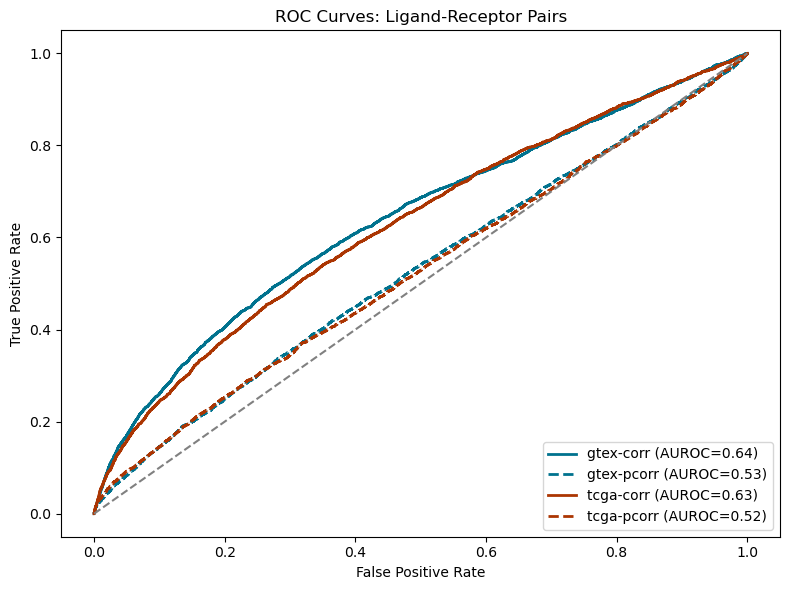

,dataset,type,n_genes,n_pairs,n_interacting,median_interacting,median_non_interacting,auroc,mannwhitney_U,mannwhitney_p
0,gtex,corr,1556,1209790,3706,0.138645,-0.003130,0.639171,2.856934e+09,4.615421e-189
1,gtex,pcorr,1556,1209790,3706,0.001919,0.000089,0.528396,2.361799e+09,1.121358e-09
2,tcga,corr,1556,1209790,3706,0.098768,0.022088,0.627564,2.805052e+09,3.232016e-159
3,tcga,pcorr,1556,1209790,3706,0.001360,0.000054,0.524392,2.343901e+09,1.402721e-07


In [39]:
# THIS CELL DOESN'T SAVE RESULTS SO YOU CAN TEST DIFFERENT PARAMETERS

# INTACT!!!

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import mannwhitneyu
import pingouin as pg

# -------------------------
# PARAMETERS
# -------------------------

# -------------------------
# LOAD INTERACTIONS
# -------------------------
#interactions = pd.read_csv(
#    "/home/lnemati/pathway_crosstalk/data/interactions/intact_direct.csv"
#)
interactions = pd.read_csv(
    "/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv"
)
interactions['all_genes'] = interactions['all_genes'].apply(literal_eval)
interactions['interactor1'] = interactions['all_genes'].apply(lambda x: x[0])
interactions['interactor2'] = interactions['all_genes'].apply(lambda x: x[1])
int_pairs = set(zip(interactions.interactor1, interactions.interactor2))
int_pairs

# Colors & line styles
colors = {"tcga": '#ab3502ff', "gtex": '#00728eff'}
linestyles = {"corr": "solid", "pcorr": "dashed"}

# -------------------------
# FIND COMMON GENES IF REQUESTED
# -------------------------
use_common_genes = False  # True = only genes present in both datasets; False = all genes

if use_common_genes:
    gtex_genes = set(gtex_matrices["corr"].index)
    tcga_genes = set(tcga_matrices["corr"].index)
    common_genes = gtex_genes & tcga_genes
    print(f"Number of common genes: {len(common_genes)}")
else:
    common_genes = None

# -------------------------
# ANALYSIS + PLOTTING
# -------------------------
results = []
plt.figure(figsize=(8, 6))

for dataset_name in ["gtex", "tcga"]:
    print(dataset_name)
    matrices = globals()[f"{dataset_name}_matrices"]
    for corr_type in ["corr", "pcorr"]:
        print(corr_type)
        mat = matrices[corr_type]

        # Subset to common genes if requested
        if use_common_genes:
            mat = mat.loc[mat.index.intersection(common_genes),
                          mat.columns.intersection(common_genes)]

        genes = set(mat.index)
        valid_pairs = {(l, r) for l, r in int_pairs if (l in genes and r in genes and l != r)}

        # Flatten lower triangle for symmetric matrices
        pairs = pd.DataFrame(
            mat.where(np.tri(mat.shape[0], k=-1, dtype=bool)).stack(),
            columns=["value"]
        ).dropna()

        # Label LR interactions
        pairs["interaction"] = [
            1 if (g1, g2) in valid_pairs or (g2, g1) in valid_pairs else 0
            for g1, g2 in pairs.index
        ]

        interacting = pairs.loc[pairs.interaction == 1, "value"]
        non_interacting = pairs.loc[pairs.interaction == 0, "value"]

        # Statistics
        if pairs["interaction"].nunique() < 2:
            auroc = np.nan
            U, p = np.nan, np.nan
            fpr, tpr, _ = [np.array([0, 1])] * 3
        else:
            auroc = roc_auc_score(pairs["interaction"], pairs["value"])
            U, p = mannwhitneyu(interacting, non_interacting, alternative="greater")
            fpr, tpr, _ = roc_curve(pairs["interaction"], pairs["value"])

        results.append({
            "dataset": dataset_name,
            "type": corr_type,
            "n_genes": mat.shape[0],
            "n_pairs": len(pairs),
            "n_interacting": int(pairs.interaction.sum()),
            "median_interacting": interacting.median(),
            "median_non_interacting": non_interacting.median(),
            "auroc": auroc,
            "mannwhitney_U": U,
            "mannwhitney_p": p
        })

        # Plot ROC curve
        plt.plot(
            fpr, tpr,
            label=f"{dataset_name}-{corr_type} (AUROC={auroc:.2f})",
            color=colors[dataset_name],
            linestyle=linestyles[corr_type],
            linewidth=2
        )

# -------------------------
# Finalize figure
# -------------------------
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Ligand-Receptor Pairs")
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Results table in memory only
results_df = pd.DataFrame(results).sort_values(["dataset", "type"])
results_df

In [45]:
import numpy as np
import pandas as pd
import pingouin as pg
from numpy.linalg import inv, LinAlgError, norm
from tqdm import tqdm

np.random.seed(42)

# -------------------------
# PARAMETERS
# -------------------------
p = 1500
true_density = 0.01
sample_sizes = [200, 400, 600, 800, 1000, 1200, 1500, 2000, 5000, 10000, 20000]

# -------------------------
# CREATE TRUE PRECISION MATRIX
# -------------------------
precision_true = np.zeros((p, p))

edges = np.random.rand(p, p) < true_density
precision_true[edges] = np.random.uniform(0.2, 0.6, edges.sum())
precision_true = np.triu(precision_true, 1)
precision_true += precision_true.T

np.fill_diagonal(precision_true, 1)
precision_true += np.eye(p) * 0.5  # ensure PD

cov_true = inv(precision_true)

# true partial correlations
d = np.sqrt(np.diag(precision_true))
pcorr_true = -precision_true / np.outer(d, d)
np.fill_diagonal(pcorr_true, 1)

tri = np.tril_indices(p, k=-1)
true_vals = pcorr_true[tri]

# -------------------------
# BENCHMARK
# -------------------------
results = []

for n in tqdm(sample_sizes):
    try:
        # simulate data
        X = np.random.multivariate_normal(np.zeros(p), cov_true, size=n)
        df = pd.DataFrame(X)

        # estimate partial correlation via pingouin
        pcorr_est = pg.pcorr(df).values

        est_vals = pcorr_est[tri]

        corr_recovery = np.corrcoef(true_vals, est_vals)[0, 1]
        frob_error = norm(pcorr_true - pcorr_est, ord="fro") / p
        stability = np.std(est_vals)

        results.append({
            "samples": n,
            "pcorr_similarity": corr_recovery,
            "frobenius_error": frob_error,
            "std_estimates": stability,
            "status": "ok"
        })

    except LinAlgError:
        results.append({
            "samples": n,
            "pcorr_similarity": np.nan,
            "frobenius_error": np.nan,
            "std_estimates": np.nan,
            "status": "singular matrix"
        })

results_df = pd.DataFrame(results)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(results_df.samples, results_df.pcorr_similarity, marker='o')
plt.xlabel("Number of samples")
plt.ylabel("Similarity to true pcorr")
plt.title("Pingouin Partial Correlation Stability (p=1000)")
plt.grid(alpha=0.3)
plt.show()

  0%|          | 0/11 [00:00<?, ?it/s]/var/tmp/pbs.415445.pbs01/ipykernel_23086/732684056.py:47: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(np.zeros(p), cov_true, size=n)
  9%|▉         | 1/11 [00:01<00:10,  1.05s/it]/var/tmp/pbs.415445.pbs01/ipykernel_23086/732684056.py:47: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(np.zeros(p), cov_true, size=n)
 18%|█▊        | 2/11 [00:02<00:09,  1.06s/it]/var/tmp/pbs.415445.pbs01/ipykernel_23086/732684056.py:47: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(np.zeros(p), cov_true, size=n)
 27%|██▋       | 3/11 [00:03<00:08,  1.05s/it]/var/tmp/pbs.415445.pbs01/ipykernel_23086/732684056.py:47: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(np.zeros(p), cov_true, size=n)
 36%|███▋      | 4/11 [00:04<00:07,  1.03s/it]/var/t

,samples,pcorr_similarity,frobenius_error,std_estimates,status
0,200,-0.154167,0.089771,0.081123,ok
1,400,-0.126706,0.069328,0.059999,ok
2,600,-0.058584,0.060806,0.052378,ok
3,800,0.030312,0.056621,0.050083,ok
4,1000,0.111357,0.056406,0.052192,ok
5,1200,0.161443,0.064174,0.062463,ok
6,1500,0.034850,0.431573,0.431785,ok
7,2000,0.329919,0.047021,0.048186,ok
8,5000,0.649049,0.022132,0.024452,ok
9,10000,0.763426,0.018003,0.020772,ok


  0%|          | 0/6 [00:00<?, ?it/s]/var/tmp/pbs.415523.pbs01/ipykernel_26444/3437489776.py:49: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(np.zeros(p), cov_true, size=n)
 17%|█▋        | 1/6 [00:00<00:03,  1.39it/s]/var/tmp/pbs.415523.pbs01/ipykernel_26444/3437489776.py:49: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(np.zeros(p), cov_true, size=n)
 33%|███▎      | 2/6 [00:01<00:02,  1.41it/s]/var/tmp/pbs.415523.pbs01/ipykernel_26444/3437489776.py:49: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(np.zeros(p), cov_true, size=n)
 50%|█████     | 3/6 [00:02<00:02,  1.36it/s]/var/tmp/pbs.415523.pbs01/ipykernel_26444/3437489776.py:49: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(np.zeros(p), cov_true, size=n)
 67%|██████▋   | 4/6 [00:03<00:01,  1.06it/s]/var/tm

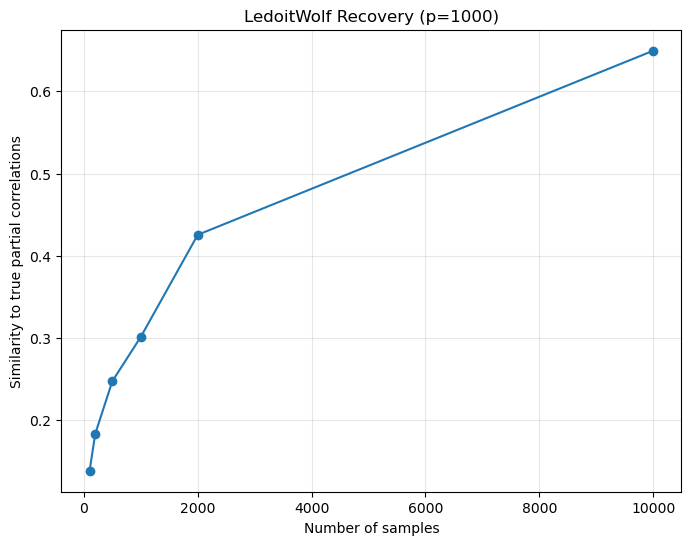

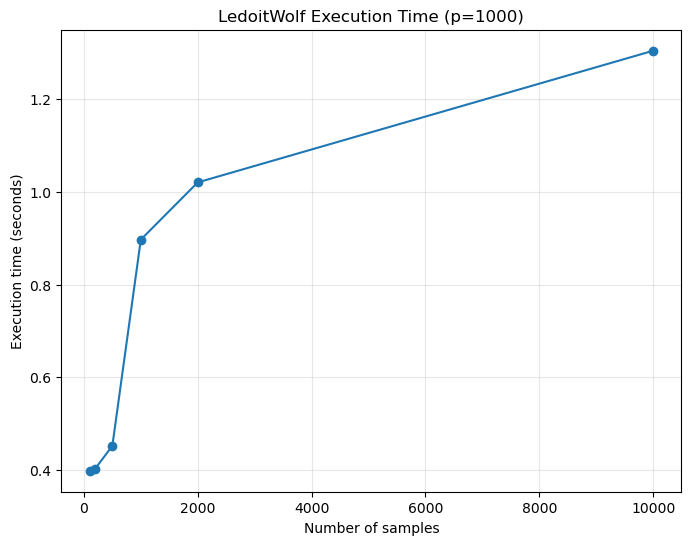

In [16]:
import numpy as np
import pandas as pd
from numpy.linalg import inv
from sklearn.covariance import LedoitWolf
from scipy.stats import spearmanr
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

np.random.seed(42)

# -------------------------
# PARAMETERS
# -------------------------
p = 1000
true_density = 0.02
sample_sizes = [p//10, p//5, p//2, p, 2*p, 10*p]

# -------------------------
# CREATE TRUE PRECISION MATRIX
# -------------------------
precision_true = np.zeros((p, p))

edges = np.random.rand(p, p) < true_density
precision_true[edges] = np.random.uniform(0.3, 0.8, edges.sum())
precision_true = np.triu(precision_true, 1)
precision_true += precision_true.T

np.fill_diagonal(precision_true, 1)
precision_true += np.eye(p) * 0.5  # ensure PD

cov_true = inv(precision_true)

# true partial correlations
d = np.sqrt(np.diag(precision_true))
pcorr_true = -precision_true / np.outer(d, d)
np.fill_diagonal(pcorr_true, 1)

tri = np.tril_indices(p, k=-1)
true_vals = pcorr_true[tri]

# -------------------------
# BENCHMARK
# -------------------------
results = []

for n in tqdm(sample_sizes):

    X = np.random.multivariate_normal(np.zeros(p), cov_true, size=n)

    # ------------------
    # Ledoit-Wolf
    # ------------------
    start = time.perf_counter()
    lw = LedoitWolf()
    lw.fit(X)
    lw_time = time.perf_counter() - start

    cov_lw = lw.covariance_
    precision_lw = inv(cov_lw)

    d_lw = np.sqrt(np.diag(precision_lw))
    pcorr_lw = -precision_lw / np.outer(d_lw, d_lw)
    np.fill_diagonal(pcorr_lw, 1)
    vals_lw = pcorr_lw[tri]

    results.append({
        "samples": n,
        "pcorr_similarity": np.corrcoef(true_vals, vals_lw)[0, 1], # pearson
        "execution_time": lw_time
    })

results_df = pd.DataFrame(results)

# -------------------------
# PLOT 1: Recovery
# -------------------------
plt.figure(figsize=(8,6))
plt.plot(results_df.samples, results_df.pcorr_similarity, marker='o')
plt.xlabel("Number of samples")
plt.ylabel("Similarity to true partial correlations")
plt.title(f"LedoitWolf Recovery (p={p})")
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# PLOT 2: Execution Time
# -------------------------
plt.figure(figsize=(8,6))
plt.plot(results_df.samples, results_df.execution_time, marker='o')
plt.xlabel("Number of samples")
plt.ylabel("Execution time (seconds)")
plt.title(f"LedoitWolf Execution Time (p={p})")
plt.grid(alpha=0.3)
plt.show()

In [14]:
spearmanr(true_vals, vals_lw).correlation

np.float64(0.2544624320043062)


Processing gtex corr

Processing gtex pcorr

Processing tcga corr

Processing tcga pcorr


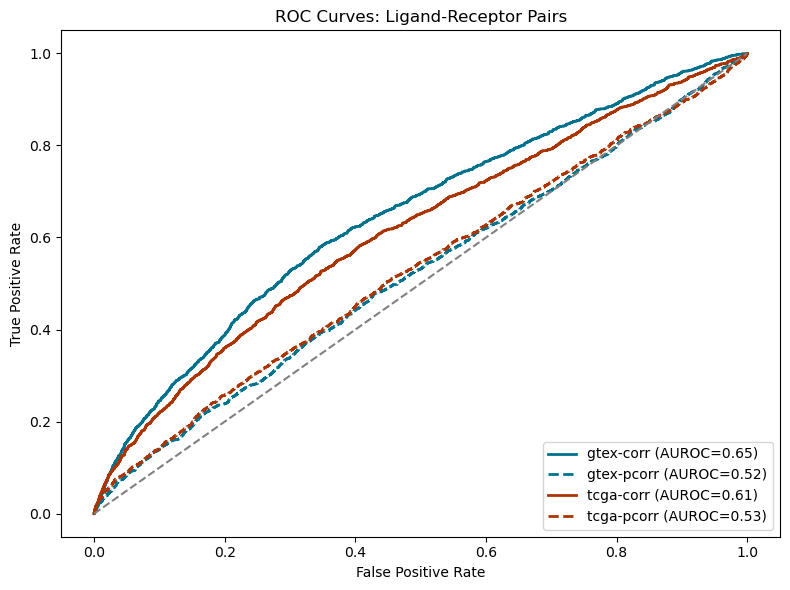


Saved results table and ROC figure.


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import mannwhitneyu

import numpy as np
import pandas as pd
import pingouin as pg

for adata, name in [(gtex, "gtex"), (tcga, "tcga")]:

    # convert expression matrix to DataFrame (samples × genes)
    geneExp = pd.DataFrame(
        adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X,
        columns=adata.var_names
    )

    # Pearson correlation

    corr = geneExp.corr(method="pearson")

    corr.to_csv(
        f"/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/{name}_corr.csv"
    )

    # Partial correlation (Pingouin)

    pcorr = pg.pcorr(geneExp)

    pcorr.to_csv(
        f"/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/{name}_pcorr.csv"
    )

# -------------------------
# PARAMETERS
# -------------------------
use_common_genes = False  # True = only genes present in both datasets; False = use all genes

# -------------------------
# LOAD LR INTERACTIONS
# -------------------------
interactions = pd.read_csv(
    "/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv"
)
lr_pairs = set(zip(interactions.ligand, interactions.receptor))

# Colors & line styles
colors = {"tcga": '#ab3502ff', "gtex": '#00728eff'}
linestyles = {"corr": "solid", "pcorr": "dashed"}

# -------------------------
# PATHS TO MATRICES
# -------------------------
paths = {
    "gtex": {
        "corr": "/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex_corr.csv",
        "pcorr": "/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex_pcorr.csv"
    },
    "tcga": {
        "corr": "/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga_corr.csv",
        "pcorr": "/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga_pcorr.csv"
    }
}

# -------------------------
# LOAD MATRICES TO FIND COMMON GENES
# -------------------------
if use_common_genes:
    gtex_genes = set(pd.read_csv(paths["gtex"]["corr"], index_col=0).index)
    tcga_genes = set(pd.read_csv(paths["tcga"]["corr"], index_col=0).index)
    common_genes = gtex_genes & tcga_genes
    print(f"Number of common genes: {len(common_genes)}")
else:
    common_genes = None

# -------------------------
# ANALYSIS + PLOTTING
# -------------------------
results = []
plt.figure(figsize=(8, 6))

for dataset, mats in paths.items():
    for corr_type, path in mats.items():
        print(f"\nProcessing {dataset} {corr_type}")

        mat = pd.read_csv(path, index_col=0)

        # Subset to common genes if requested
        if use_common_genes:
            mat = mat.loc[mat.index.intersection(common_genes), mat.columns.intersection(common_genes)]

        genes = set(mat.index)
        valid_pairs = {(l, r) for l, r in lr_pairs if l in genes and r in genes}

        # Flatten lower triangle for symmetric matrices
        pairs = pd.DataFrame(
            mat.where(np.tri(mat.shape[0], k=-1, dtype=bool))
               .stack(),
            columns=["value"]
        ).dropna()

        # Label LR interactions
        pairs["interaction"] = [
            1 if (g1, g2) in valid_pairs or (g2, g1) in valid_pairs else 0
            for g1, g2 in pairs.index
        ]

        interacting = pairs.loc[pairs.interaction == 1, "value"]
        non_interacting = pairs.loc[pairs.interaction == 0, "value"]

        # Statistics
        if pairs["interaction"].nunique() < 2:
            auroc = np.nan
            U, p = np.nan, np.nan
            fpr, tpr, _ = [np.array([0, 1])] * 3
        else:
            auroc = roc_auc_score(pairs["interaction"], pairs["value"])
            U, p = mannwhitneyu(interacting, non_interacting, alternative="greater")
            fpr, tpr, _ = roc_curve(pairs["interaction"], pairs["value"])

        results.append({
            "dataset": dataset,
            "type": corr_type,
            "n_genes": mat.shape[0],
            "n_pairs": len(pairs),
            "n_interacting": int(pairs.interaction.sum()),
            "median_interacting": interacting.median(),
            "median_non_interacting": non_interacting.median(),
            "auroc": auroc,
            "mannwhitney_U": U,
            "mannwhitney_p": p
        })

        # Plot ROC curve
        plt.plot(
            fpr, tpr,
            label=f"{dataset}-{corr_type} (AUROC={auroc:.2f})",
            color=colors[dataset],
            linestyle=linestyles[corr_type],
            linewidth=2
        )

# -------------------------
# Finalize figure
# -------------------------
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Ligand-Receptor Pairs")
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()

# Save figure (overwrite previous)
plt.savefig("lr_pairs_roc_curves.png", dpi=300)
plt.show()

# Save results (overwrite previous)
results_df = pd.DataFrame(results).sort_values(["dataset", "type"])
results_df.to_csv("lr_interaction_vs_all_stats.csv", index=False)
print("\nSaved results table and ROC figure.")